<h1 style="text-align: center;">Hotel Booking Cancellation Prediction Using Machine Learning</h1>
<h3 style="text-align: center;">Valencia & Muhammad Rafi Andrianto</h3>

---

## **Section 0. Setup**

### **0.1 Import Library**

In [1]:
# common library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Feature Engineering
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from category_encoders import BinaryEncoder
from feature_engine.outliers import Winsorizer, OutlierTrimmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from feature_engine.selection import DropFeatures
from feature_engine.datetime import DatetimeFeatures

# Model and pipelining
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    ExtraTreesClassifier, 
    BaggingClassifier, 
    AdaBoostClassifier, 
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import cross_validate, RandomizedSearchCV, GridSearchCV, StratifiedKFold
import shap

# Imbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Save Model
import pickle

### **0.2 Global Configuration**

In [2]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

---

## **Section 1. Business Understanding**

**Background**

Hotel booking cancellations create uncertainty in occupancy planning and reduce potential revenue. This project analyzes hotel booking data from a hotel in Portugal to develop a machine learning model that predicts whether a customer will cancel their reservation. Early identification of booking cancellations enables hotels to reduce revenue loss, optimize room occupancy, and improve operational planning.

**Key Stakeholders**
- Hotel General Manager: responsible for hotel performance and business strategy.
- Revenue Management Team: responsible for hotel pricing, occupancy, and revenue.
- Front Office Team: responsible for room reservations, booking policies and coordinating guest arrivals and room allocation.
- Data Science Team: provides analytical insights and builds predictive tools to support business decisions.

**Problem Statement**

Hotel booking cancellations represent a significant operational and financial challenge for the hotel. With a substantial number of reservations being canceled before check-in, the hotel faces:
- **Revenue loss** from rooms that remain vacant because canceled bookings cannot always be replaced in time.
- **Operational challenges** in managing room allocation and staff planning..
- **Difficulty managing room availability and pricing**, reducing opportunities to maximize occupancy and revenue.
- **Difficulty forecasting future bookings**, making it harder to plan hotel operations and promotions.

Without accurately identifying customers who are likely to cancel, the hotel cannot proactively implement strategies such as deposit requirements, personalized reminders, or targeted retention offers to minimize cancellations and improve occupancy rates.

**Goals**

To address this challenge, the hotel aims to:
- **Analyze cancellation patterns**: Identify the booking characteristics and customer behaviors that are most associated with booking cancellations.
- **Build a predictive machine learning model**: Develop and evaluate a model that can identify customers who are likely to cancel their reservations before check-in.
- **Support proactive decision-makin**g: Enable hotel teams to take preventive actions, such as sending booking reminders, requiring deposits, or offering personalized incentives to reduce cancellations and improve room occupancy.

**Metric Evaluations**

**Type I Error (False Positive)**
- Prediction: The booking will be canceled.
- Actual: The booking is **not** canceled.

Consequence:

The hotel takes unnecessary actions, such as sending additional reminders, requesting a deposit, or offering incentives.
This increases operational costs and may negatively affect the customer experience.

**Type II Error (False Negative)**
- Prediction: The booking will not be canceled.
- Actual: The booking is canceled.

Consequence:

The hotel misses the opportunity to take preventive actions.
The room may remain vacant, resulting in lower occupancy and lost revenue.

---
## **Section 2. Data Understanding**
This section provides an overview of the dataset's structure, including its size and format, before performing data cleaning.

### **2.1 General Information**

In [3]:
# Load Dataset
df = pd.read_csv('../data/raw/data_hotel_booking_demand.csv')
df.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [4]:
# Dataset Dimension
print(f"Dataset Dimension: {df.shape}")

Dataset Dimension: (83573, 11)


In [5]:
# Count and Datatype for each Column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   country                      83222 non-null  str  
 1   market_segment               83573 non-null  str  
 2   previous_cancellations       83573 non-null  int64
 3   booking_changes              83573 non-null  int64
 4   deposit_type                 83573 non-null  str  
 5   days_in_waiting_list         83573 non-null  int64
 6   customer_type                83573 non-null  str  
 7   reserved_room_type           83573 non-null  str  
 8   required_car_parking_spaces  83573 non-null  int64
 9   total_of_special_requests    83573 non-null  int64
 10  is_canceled                  83573 non-null  int64
dtypes: int64(6), str(5)
memory usage: 9.7 MB


### **2.2 Feature Information**

**Features Identification**

| Column | Type | Description |
| --- | --- | --- |
| country |string| Country of origin.|
| market_segment|string|Market segment designation. |
| previous_cancellations|integer| Number of previous bookings that were cancelled by the customer prior to the current booking|
| booking_changes|integer| Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation|
| deposit_type|string| Indication on if the customer made a deposit to guarantee the booking.|
| days_in_waiting_list|integer| Number of days the booking was in the waiting list before it was confirmed to the customer|
| customer_type|string| Type of booking|
| reserved_room_type|string| Code of room type reserved. Code is presented instead of designation for anonymity reasons|
| required_car_parking_space|integer| Number of car parking spaces required by the customer|
| total_of_special_request|integer| Number of special requests made by the customer (e.g. twin bed or high floor)|
| is_canceled|integer| Value indicating if the booking was canceled (1) or not (0)|


### **2.3 Statistics Summary**

#### **2.3.1 Descriptive Statistics of Numerical Features**

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
previous_cancellations,83573.0,0.086798,0.841011,0.0,0.0,0.0,0.0,26.0
booking_changes,83573.0,0.220897,0.648635,0.0,0.0,0.0,0.0,21.0
days_in_waiting_list,83573.0,2.330561,17.673051,0.0,0.0,0.0,0.0,391.0
required_car_parking_spaces,83573.0,0.062999,0.246919,0.0,0.0,0.0,0.0,8.0
total_of_special_requests,83573.0,0.573211,0.795163,0.0,0.0,0.0,1.0,5.0
is_canceled,83573.0,0.368277,0.482340,0.0,0.0,0.0,1.0,1.0


#### **2.3.2 Descriptive Statistics of Categorical Features**

In [7]:
df.describe(include='object').T

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
country,83222,162,PRT,34097
market_segment,83573,8,Online TA,39460
deposit_type,83573,3,No Deposit,73352
customer_type,83573,4,Transient,62732
reserved_room_type,83573,10,A,60041


---

## **Section 3. Data Cleaning**

### **3.1 Missing Values**
Identify columns with missing values and determine the appropriate handling strategy, such as dropping, imputing, or retaining them based on business and analytical considerations.

In [8]:
# check missing value
df.isnull().sum()

country                        351
market_segment                   0
previous_cancellations           0
booking_changes                  0
deposit_type                     0
days_in_waiting_list             0
customer_type                    0
reserved_room_type               0
required_car_parking_spaces      0
total_of_special_requests        0
is_canceled                      0
dtype: int64

> The `country` column contains 351 missing values. We can either drop them or label them as 'unknown', but for now we will drop them.

In [9]:
# Drop
df.dropna(subset=['country'], inplace=True)
df.isnull().sum()

country                        0
market_segment                 0
previous_cancellations         0
booking_changes                0
deposit_type                   0
days_in_waiting_list           0
customer_type                  0
reserved_room_type             0
required_car_parking_spaces    0
total_of_special_requests      0
is_canceled                    0
dtype: int64

### **3.2 Duplicated Values**

In [10]:
# check duplicated values
# Identify fully duplicated records across all columns

total_duplicates = df.duplicated().sum()
percentage_duplicates = (total_duplicates / len(df)) * 100

print(total_duplicates)
print(f"Percentage: {percentage_duplicates:.2f}%")

73138
Percentage: 87.88%


> No duplicates were removed because the dataset has no unique transaction ID.

### **3.3 Data Consistency Check**
- Check for spelling errors or typos in categorical values.
- Check for inconsistent capitalization and formatting.
- Check for leading, trailing, or hidden whitespace characters.

In [11]:
# Remove hidden whitespace from the beginning/end of strings (if any) and standardize text casing
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/200614727.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


### **3.4 Identify Anomaly Values**
In this section, we inspect our categorical and numerical features for statistical anomalies, high cardinality, rare categories, and extreme numerical outliers. Managing these anomalies is crucial for preventing overfitting and ensuring our models generalize well.

#### 3.4.1 Categorical Features
Checking the cardinality (number of unique values) and look for categories with extremely low frequency. If a categorical feature has too many unique values or contains categories with extremely low frequencies (<0.1% of the dataset), it can lead to overfitting or inefficiency during encoding.

In [12]:
# Check unique values and distribution of categorical features
categorical_features = ['country', 'market_segment', 'deposit_type', 'customer_type', 'reserved_room_type']

# Threshold
threshold_pct = 0.1

for i in categorical_features:
    print(f"\n--- Column: {i} ---")
    print(f"Total Unique: {df[i].nunique(dropna=False)}")
    print("Distribution:")

    counts = df[i].value_counts(dropna=False)
    pcts = df[i].value_counts(dropna=False, normalize=True) * 100

    for idx, (val, count, pct) in enumerate(zip(counts.index, counts.values, pcts.values)):
        flag = " [LOW]" if pct < threshold_pct else ""
        print(f" {idx+1}. {val}: {count} ({pct:.3f}%){flag}")



--- Column: country ---
Total Unique: 162
Distribution:
 1. PRT: 34097 (40.971%)
 2. GBR: 8495 (10.208%)
 3. FRA: 7307 (8.780%)
 4. ESP: 5996 (7.205%)
 5. DEU: 5116 (6.147%)
 6. ITA: 2658 (3.194%)
 7. IRL: 2340 (2.812%)
 8. BEL: 1648 (1.980%)
 9. BRA: 1553 (1.866%)
 10. USA: 1472 (1.769%)
 11. NLD: 1433 (1.722%)
 12. CHE: 1201 (1.443%)
 13. CN: 886 (1.065%)
 14. AUT: 873 (1.049%)
 15. SWE: 724 (0.870%)
 16. CHN: 709 (0.852%)
 17. POL: 638 (0.767%)
 18. ISR: 463 (0.556%)
 19. RUS: 435 (0.523%)
 20. NOR: 431 (0.518%)
 21. ROU: 341 (0.410%)
 22. FIN: 316 (0.380%)
 23. DNK: 308 (0.370%)
 24. AUS: 301 (0.362%)
 25. AGO: 243 (0.292%)
 26. LUX: 181 (0.217%)
 27. MAR: 179 (0.215%)
 28. TUR: 163 (0.196%)
 29. ARG: 154 (0.185%)
 30. HUN: 138 (0.166%)
 31. JPN: 129 (0.155%)
 32. CZE: 117 (0.141%)
 33. IND: 104 (0.125%)
 34. KOR: 102 (0.123%)
 35. GRC: 94 (0.113%)
 36. SRB: 81 (0.097%) [LOW]
 37. DZA: 80 (0.096%) [LOW]
 38. HRV: 73 (0.088%) [LOW]
 39. IRN: 63 (0.076%) [LOW]
 40. ZAF: 60 (0.072%) 


| Feature | Identified Anomaly / Rare Category | Decision | Business & Technical Justification |
| :--- | :--- | :--- | :--- |
|  `country` | 127 countries have a frequency $< 0.1\%$ (from SRB to AIA). | Keep | Dropping the column would lose valuable geographic signals (domestic vs. international customer behaviors). However, keeping 162 unique categories would cause the very huge dimensionality during one-hot encoding. *(maybe during feature engineering, we will group all countries with a frequency $< 1\%$ into a single 'Other' category. so we do binning (?))* |
| `market_segment` | 'Undefined' has only 1 occurrence ($0.001\%$). | Drop | A single instance represents noise or a data entry error. It holds no predictive power and can introduce zero-variance issues in dummy variables. We will drop this single row. |
| `deposit_type` | None (Lowest is 'Refundable' at $0.132\%$, which is above our $0.1\%$ threshold). | Keep | The category distributions are healthy and reflect actual financial terms of bookings. |
| `customer_type` | None (Lowest is 'Group' at $0.503\%$). | Keep | No anomalies detected; all values represent distinct and valid customer profiles. |
| `reserved_room_type` | 'L' (3 rows, $0.004\%$) and 'P' (2 rows, $0.002\%$) are extremely rare. | Keep | Dropping the column is not an option as room type dictates pricing and preference. |


In [13]:
# Filtering 1 'Undefined' value on the column market_segment
display(df[df['market_segment'] == 'Undefined'])

print(f"Rows Before: {len(df)}")
df = df[df['market_segment'] != 'Undefined']
print(f"Rows After: {len(df)}")

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
70217,PRT,Undefined,0,0,No Deposit,0,Transient-Party,B,0,1,1


Rows Before: 83222
Rows After: 83221


#### 3.4.1 Numerical Features
Checking the distributions, skewness, and extreme outliers. For Numericals, we check for extreme outliers using both visual boxplots and quantitative descriptive statistics.

In [14]:
# Check unique values and distribution of numerical features
numerical_features = ['previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']

for col in numerical_features:
    print(f"\n--- Column: {col} ---")
    print(f"Total Unique: {df[col].nunique(dropna=False)}")
    print("Distribusion:")
    
    counts = df[col].value_counts(dropna=False)
    
    for idx, (val, count) in enumerate(zip(counts.index, counts.values)):
        print(f" {idx+1}. Value {val}: {count} ")


--- Column: previous_cancellations ---
Total Unique: 15
Distribusion:
 1. Value 0: 78731 
 2. Value 1: 4186 
 3. Value 2: 84 
 4. Value 3: 46 
 5. Value 24: 33 
 6. Value 11: 28 
 7. Value 6: 19 
 8. Value 4: 19 
 9. Value 26: 18 
 10. Value 25: 17 
 11. Value 19: 12 
 12. Value 13: 10 
 13. Value 14: 10 
 14. Value 5: 7 
 15. Value 21: 1 

--- Column: booking_changes ---
Total Unique: 19
Distribusion:
 1. Value 0: 70575 
 2. Value 1: 8926 
 3. Value 2: 2638 
 4. Value 3: 637 
 5. Value 4: 259 
 6. Value 5: 90 
 7. Value 6: 39 
 8. Value 7: 23 
 9. Value 8: 10 
 10. Value 10: 5 
 11. Value 9: 4 
 12. Value 13: 4 
 13. Value 17: 2 
 14. Value 12: 2 
 15. Value 14: 2 
 16. Value 16: 2 
 17. Value 21: 1 
 18. Value 20: 1 
 19. Value 15: 1 

--- Column: days_in_waiting_list ---
Total Unique: 115
Distribusion:
 1. Value 0: 80636 
 2. Value 39: 166 
 3. Value 58: 104 
 4. Value 31: 93 
 5. Value 44: 93 
 6. Value 46: 66 
 7. Value 35: 66 
 8. Value 87: 61 
 9. Value 69: 60 
 10. Value 63: 5

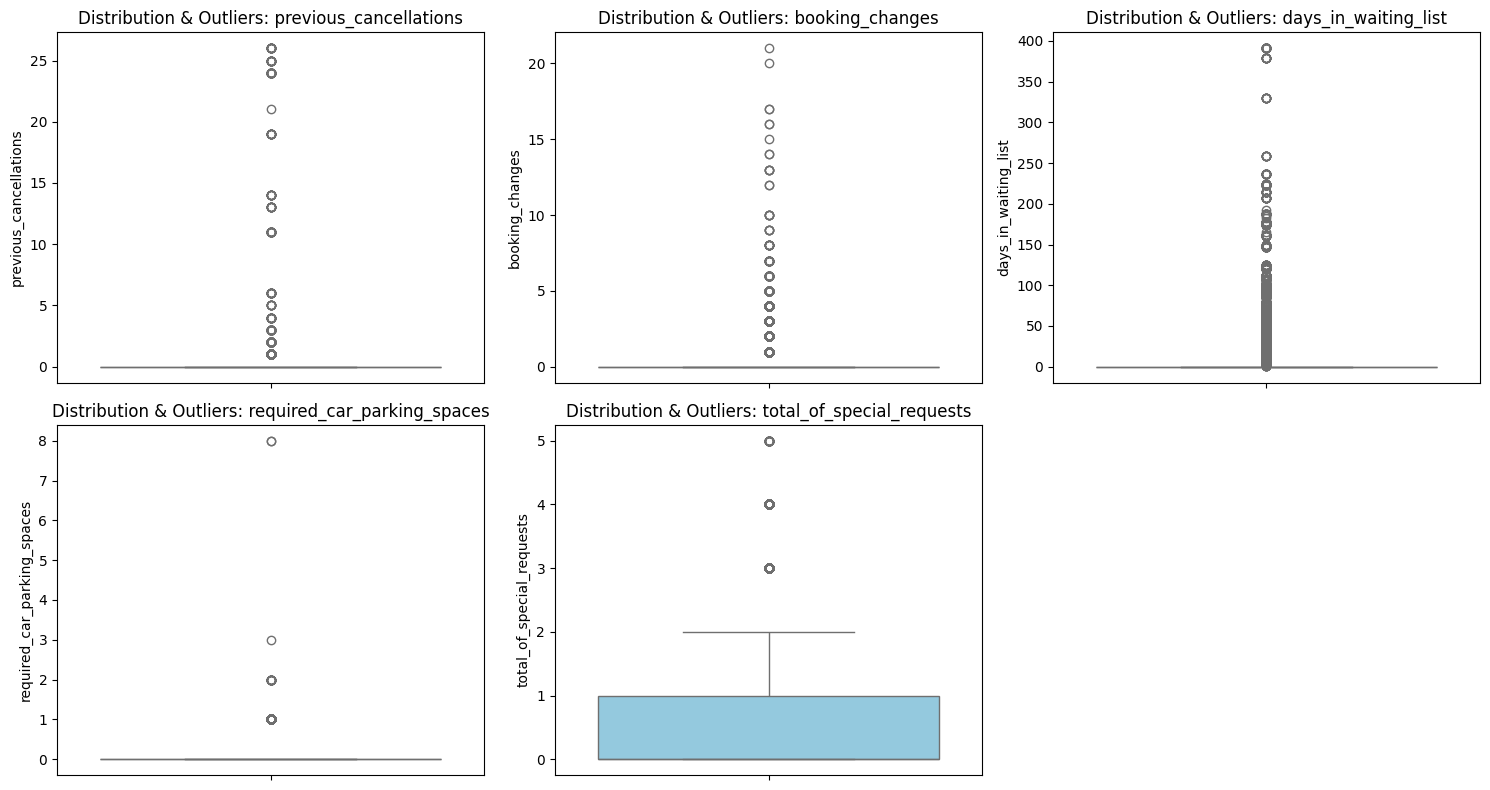

In [15]:
# Visualizing outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution & Outliers: {col}')
plt.tight_layout()
plt.show()


In [16]:
# Check skewness to check distribution shapes
for col in numerical_features:
    print(f"'{col}' Skewness = {df[col].skew():.2f}")

'previous_cancellations' Skewness = 24.37
'booking_changes' Skewness = 6.01
'days_in_waiting_list' Skewness = 11.86
'required_car_parking_spaces' Skewness = 4.36
'total_of_special_requests' Skewness = 1.35


All of the numerical features have positive skewness:
1. `previous_cancellations` (Skewness = 24.37): This is extremely highly right-skewed. Almost everyone has $0$ cancellations, but a tiny group of people have up to $26$ cancellations, dragging the distribution's tail incredibly far to the right.

2. `booking_changes` (Skewness = 6.01) & `required_car_parking_spaces` (Skewness = 4.36): Similarly right-skewed because most values are $0$

3. `days_in_waiting_list` (Skewness = 11.86): Heavily right-skewed due to a few bookings waiting for hundreds of days.

4. `total_of_special_requests` (Skewness = 1.35): Moderately right-skewed but forms a standard distribution.

| Feature | Action Decision | Business & Technical Justification |
| :--- | :--- | :--- |
| `previous_cancellations` | Keep | While the presence of extreme values (customers with 24 or 26 previous cancellations) makes this feature highly right-skewed, these are not data entry errors. A customer who has canceled dozens of times in the past is highly likely to cancel again. Removing these outliers would destroy a highly predictive feature for our cancellation model. |
| `booking_changes` | Keep | Most customers do not change their bookings once made. However, values like 15 or 21 changes, while rare, represent authentic customer updates (often associated with group bookings or corporate changes). |
| `days_in_waiting_list` | Keep | The majority of bookings are confirmed immediately. Long waiting times (such as 391 days) are still plausible and valid operational realities during peak seasons or high-demand events. |
| `required_car_parking_spaces` | Keep | The maximum value of 8 requested spots is highly unusual but completely realistic for large families or groups traveling together. Since there are no anomaly values (like negative parking spots), we keep the original values. |
| `total_of_special_requests` | Keep | This feature have a valid distribution with no anomaly values. |


---

## **Section 4. Exploratory Data Analysis (EDA)**

### **4.1 Univariate Analysis**
Here, we analyze single variables in isolation. It allows us to capture the distribution shape, central tendencies (like mean or mode), frequency of categories, and potential class imbalances without any external noise from other variables.


#### **Categorical**

#### **4.1.1 Distribution of Target Variable (`is_canceled`)**

In [17]:
# Check target proportion
target_counts = df['is_canceled'].value_counts()

for val, count in zip(target_counts.index, target_counts.values):
    status = "Cancel" if val == 1 else "Not Canceled"
    print(f"[Class {val}] {status}: {count} ")

[Class 0] Not Canceled: 52490 
[Class 1] Cancel: 30731 


/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/656197564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2b5c8f', '#d95f02'])


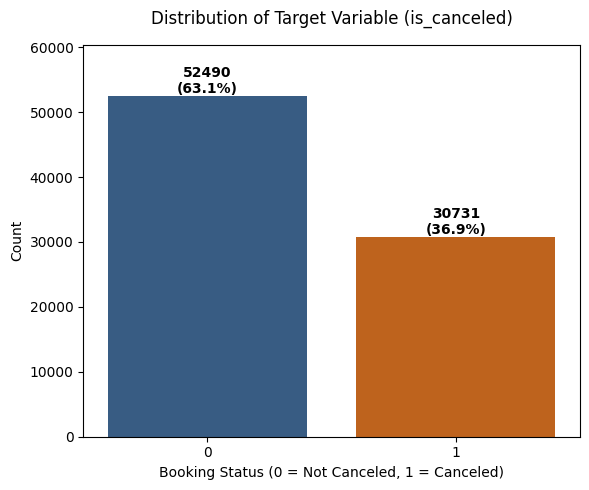

In [18]:
plt.figure(figsize=(6, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2b5c8f', '#d95f02'])

plt.title("Distribution of Target Variable (is_canceled)", pad=15)
plt.xlabel("Booking Status (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Count")

plt.ylim(0, max(target_counts.values) * 1.15)

# Add percentage and count labels on top of the bars
for idx, val in enumerate(target_counts.values):
    pct = (val / len(df)) * 100
    plt.text(idx, val, f"{val}\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


* No severe class imbalance. Since the minority class (`is_canceled` = 1) makes up **36.9%** of the data, the dataset is relatively well-balanced. We do not need to implement complex synthetic sampling methods (like SMOTE)

* While the data is balanced enough for standard training, relying purely on Accuracy can still be deceptive. To ensure we capture cancellations accurately without hurting hotel revenue with false alarms, we will evaluate our models using **Precision**, **Recall**, and the **F1-Score**.

#### **4.1.2 Distribution of `market_segment`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/3631381738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='market_segment', order=order, palette='Blues_r')


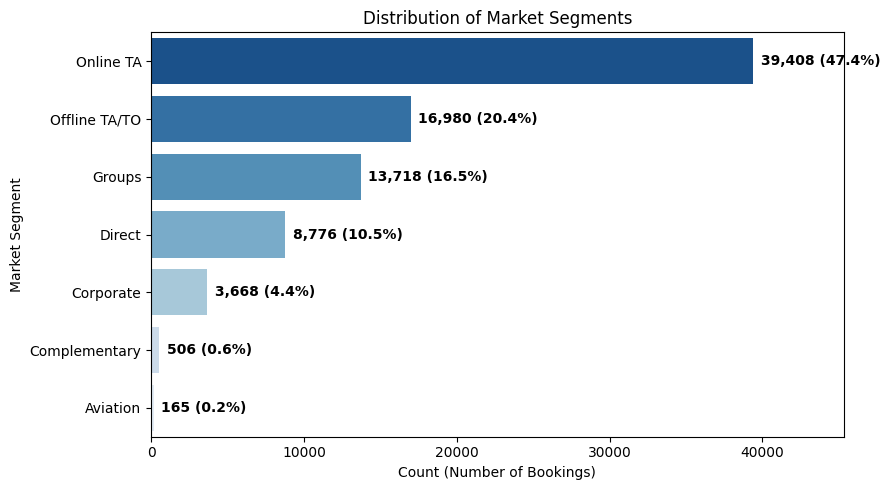

In [19]:
plt.figure(figsize=(9, 5))

order = df['market_segment'].value_counts().index
sns.countplot(data=df, y='market_segment', order=order, palette='Blues_r')

plt.title("Distribution of Market Segments")
plt.xlabel("Count (Number of Bookings)")
plt.ylabel("Market Segment")

# Adding values and percentage labels on the horizontal bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['market_segment'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(count + 500, i, f"{count:,} ({pct:.1f}%)", va='center', fontweight='bold')

plt.xlim(0, df['market_segment'].value_counts().max() * 1.15) # Add padding space for labels
plt.tight_layout()
plt.show()

* Almost half of our business (47.4%) comes through Online Travel Agencies. 

#### **4.1.3 Distribution of `deposit_type`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/2472058255.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit_type', order=order, palette='Greens_r')


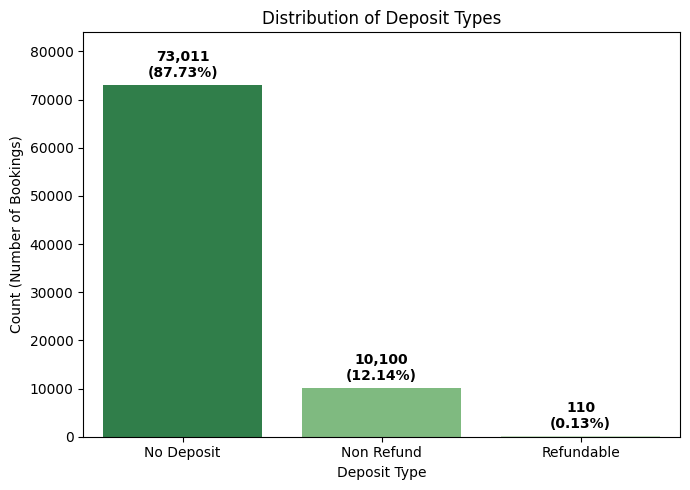

In [20]:
plt.figure(figsize=(7, 5))

order = df['deposit_type'].value_counts().index
sns.countplot(data=df, x='deposit_type', order=order, palette='Greens_r')

plt.title("Distribution of Deposit Types")
plt.xlabel("Deposit Type")
plt.ylabel("Count (Number of Bookings)")

# Adding values and percentage labels on top of the bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['deposit_type'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(i, count + 1000, f"{count:,}\n({pct:.2f}%)", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, df['deposit_type'].value_counts().max() * 1.15) # Add padding space for labels
plt.tight_layout()
plt.show()

* **87.73%** of bookings are made under a 'No Deposit' policy. This indicates that the vast majority of customers bear absolutely zero immediate financial risk if they cancel their booking. Since there are no consequences, this likely serves as a primary driver for the hotel's high cancellation rates.

* Theoretically, 'Non Refund' bookings should exhibit extremely low cancellation rates because guests lose their money. However, in our upcoming bivariate analysis, we must verify if this holds true.

#### **4.1.4 Distribution of `customer_type`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/3031918516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='customer_type', order=order, palette='Purples_r')


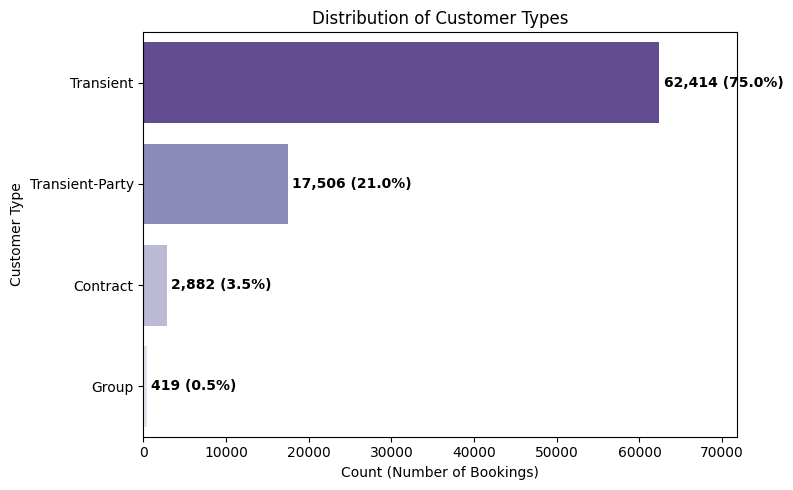

In [21]:
plt.figure(figsize=(8, 5))

order = df['customer_type'].value_counts().index
sns.countplot(data=df, y='customer_type', order=order, palette='Purples_r')

plt.title("Distribution of Customer Types")
plt.xlabel("Count (Number of Bookings)")
plt.ylabel("Customer Type")

# Adding values and percentage labels on the horizontal bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['customer_type'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(count + 500, i, f"{count:,} ({pct:.1f}%)", va='center', fontweight='bold')

plt.xlim(0, df['customer_type'].value_counts().max() * 1.15) 
plt.tight_layout()
plt.show()

* **75.0%** of the bookings belong to 'Transient' customers (walk ins, independent online bookings, or standalone reservations). These customers typically display more volatile, price sensitive behavior and lack corporate accountability, making them prime candidates for sudden adjustments or cancellations.

* **21.0%** of 'Transient-Party'. These are independent bookings but linked to another reservation (like families booking multiple rooms under separate individual names). They represent an important secondary block that might exhibit correlated cancellation behaviors (if one room in the party cancels, the others might follow).

#### **4.1.5 Distribution of `reserved_room_type`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_54286/2104926312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='reserved_room_type', order=order, palette='Reds_r')


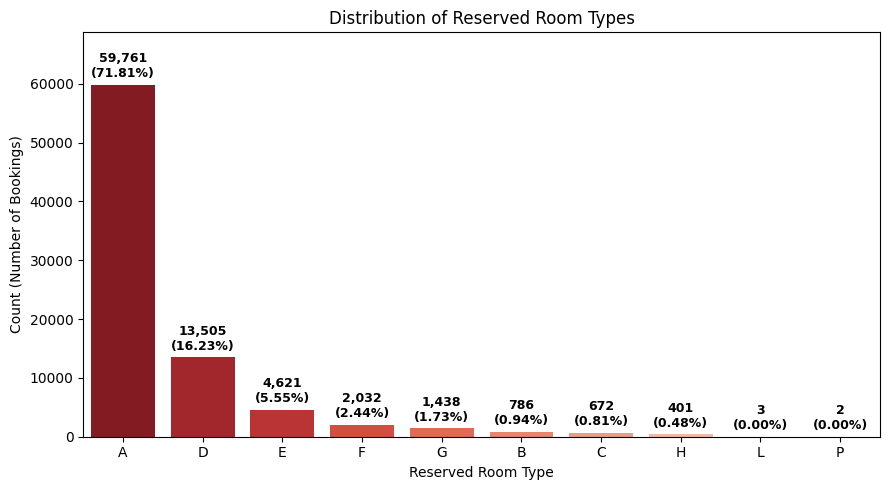

In [22]:
plt.figure(figsize=(9, 5))

order = df['reserved_room_type'].value_counts().index
sns.countplot(data=df, x='reserved_room_type', order=order, palette='Reds_r')

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Reserved Room Type")
plt.ylabel("Count (Number of Bookings)")

# Adding values and percentage labels on top of the bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['reserved_room_type'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(i, count + 800, f"{count:,}\n({pct:.2f}%)", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.ylim(0, df['reserved_room_type'].value_counts().max() * 1.15) 
plt.tight_layout()
plt.show()

* Room Type A have the most values at **71.84%**. This suggests it maybe (?) represents the standard room inventory configuration.

* The visual drop-off confirms our clean-up choice in Section 3.4. Very rare inventory categories like 'P' and 'L' are virtually invisible on the scale. Grouping them downstream protects the model from tracking sparse, noisy signals.

* Standard rooms (?) (Type A) often attract more price conscious travelers or standard business stays, which may have higher churn volatility. On the other hand, premium suites (like F or G maybe (?)) are usually tied to higher tier price points or special events, which might show different commitment behaviors.

#### **Numerical**

#### **4.1.6 Distribution of `total_of_special_requests`**

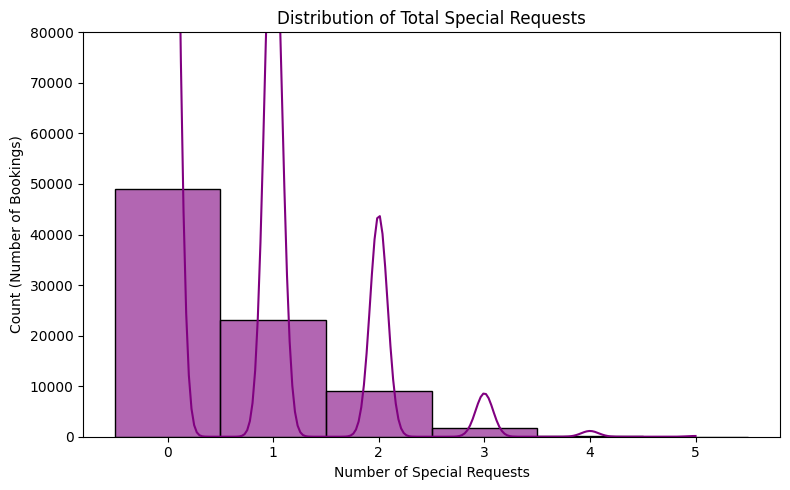

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='total_of_special_requests', kde=True, discrete=True, color='purple', alpha=0.6)

plt.title("Distribution of Total Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Count (Number of Bookings)")
plt.ylim(0, 80000)

plt.tight_layout()
plt.show()

* More than half of all guests make zero special requests. From a behavioral standpoint, making special requests reflects a higher engagement which means a customer taking the time to detail their preferences is likely more committed to the stay.

#### **4.1.7 Distribution of `booking_changes`**

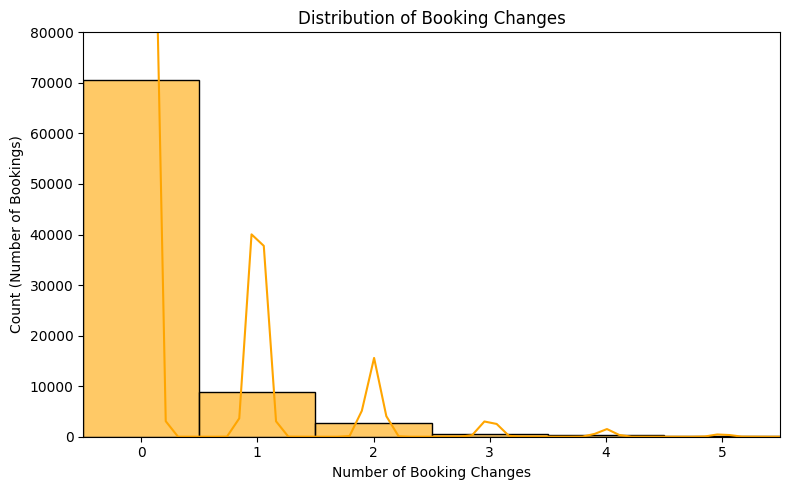

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='booking_changes', kde=True, discrete=True, color='orange', alpha=0.6)

plt.title("Distribution of Booking Changes")
plt.xlabel("Number of Booking Changes")
plt.ylabel("Count (Number of Bookings)")
plt.xlim(-0.5, 5.5)
plt.ylim(0, 80000)
plt.tight_layout()
plt.show()

* **84.80%** of reservations are never modified after creation. The majority of customers likely have a 'book and relax' approach to booking hotel accommodations.

* When a customer triggers a booking modification, it suggests they are actively customizing their stay (in a scenario where they have a change of plans in their travels).

#### **4.1.8 Distribution of `days_in_waiting_list`**

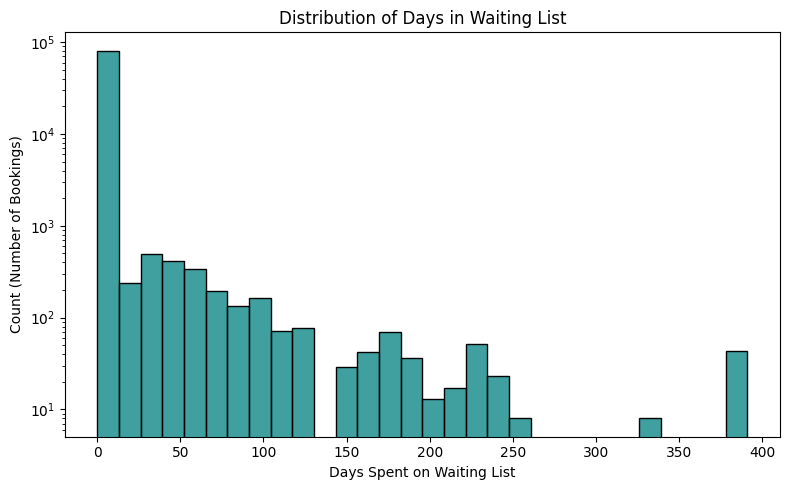

In [25]:
plt.figure(figsize=(8, 5))
# Using a slightly larger bin width because the values range up to several hundred days
sns.histplot(data=df, x='days_in_waiting_list', bins=30, color='teal')

plt.title("Distribution of Days in Waiting List")
plt.xlabel("Days Spent on Waiting List")
plt.ylabel("Count (Number of Bookings)")
plt.yscale('log') # Using a log scale helps visualize the long tail since 0 dominates completely
plt.tight_layout()
plt.show()

* A non-zero value in this column indicates an overcapacity or extreme demand periods (such as peak seasonal events or massive corporate conventions)

* A long wait time can make a customer look for another hotel.

#### **4.1.9 Distribution of `required_car_parking_spaces`**

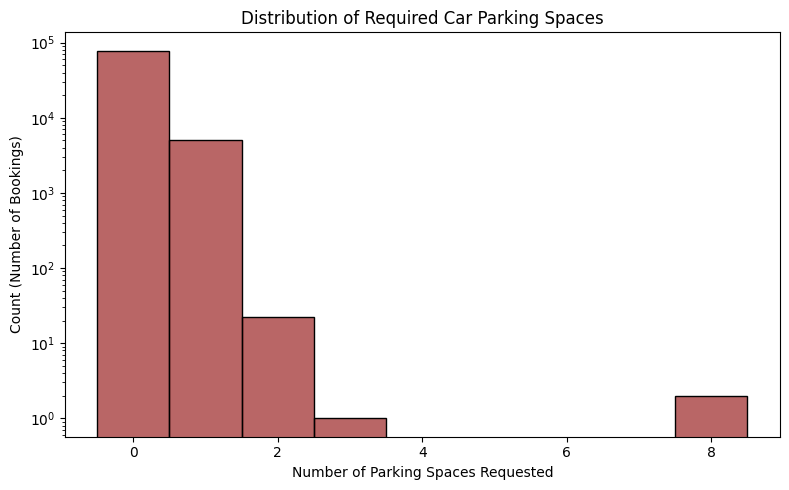

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='required_car_parking_spaces', kde=False, discrete=True, color='darkred', alpha=0.6)

plt.title("Distribution of Required Car Parking Spaces")
plt.xlabel("Number of Parking Spaces Requested")
plt.ylabel("Count (Number of Bookings)")
plt.yscale('log') # Log scale applied due to extreme zero-inflation
plt.tight_layout()
plt.show()

* Customers who requests a parking space are usually driving their own or a rental car to the hotel. Because they already have a well planned travel, they are highly committed and very unlikely to cancel their booking

* 

### **4.2 Bivariate Analysis**

#### **4.2.1 Categorical**

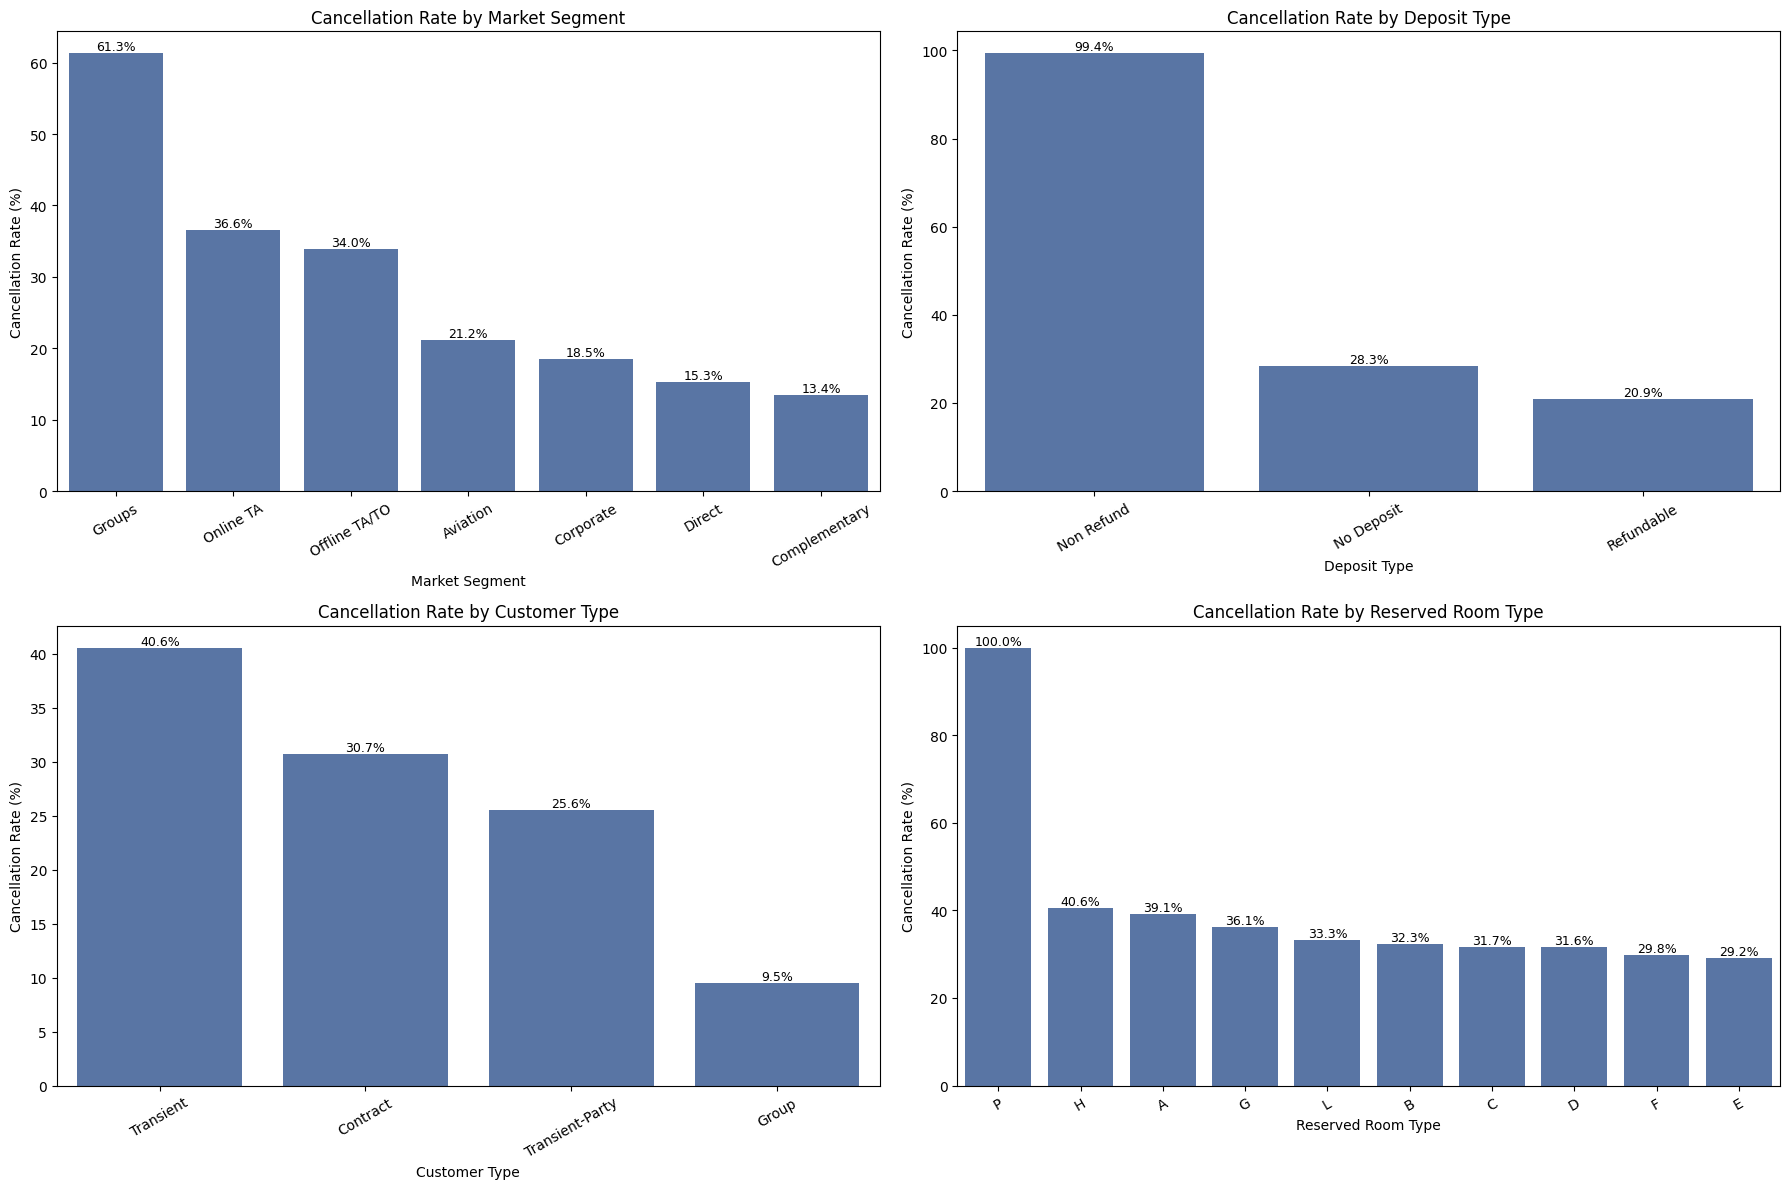

In [27]:
cat_features = [
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):

    cancel_rate = (
        df.groupby(col)['is_canceled']
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index()
    )

    ax = sns.barplot(
        data=cancel_rate,
        x=col,
        y='is_canceled',
        color='#4C72B0',
        ax=axes[i]
    )

    # Tambahkan label persentase
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9)

    ax.set_title(f'Cancellation Rate by {col.replace("_", " ").title()}')
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel('Cancellation Rate (%)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [28]:
# check sample counts
cat_features = [
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type',
    'country'
]

for col in cat_features:
    print(f"{'-'*50}")
    print(f"Value Counts: {col}")
    print(f"{'-'*50}")
    print(df[col].value_counts())

--------------------------------------------------
Value Counts: market_segment
--------------------------------------------------
market_segment
Online TA        39408
Offline TA/TO    16980
Groups           13718
Direct            8776
Corporate         3668
Complementary      506
Aviation           165
Name: count, dtype: int64
--------------------------------------------------
Value Counts: deposit_type
--------------------------------------------------
deposit_type
No Deposit    73011
Non Refund    10100
Refundable      110
Name: count, dtype: int64
--------------------------------------------------
Value Counts: customer_type
--------------------------------------------------
customer_type
Transient          62414
Transient-Party    17506
Contract            2882
Group                419
Name: count, dtype: int64
--------------------------------------------------
Value Counts: reserved_room_type
--------------------------------------------------
reserved_room_type
A    59761
D   

**Overview**:
1. "Groups" has the highest cancellation rate (61.3%), followed by Online TA (36.6%) and Offline TA (34%). These 3 market_segment have the highest cancellation risk.
2. Non-refund has the highest cancellation rate (99.4%) indicating strong association between the Non Refund deposit policy and booking cancellations.
3. Customer type 'Transient' has the highest cancellation rate(40.6%) followed by contract (30.7%) and transient-party (25.6%)
4. Room type P shows a 100% cancellation rate, but this is based on only 2 bookings and is therefore not representative. Excluding this category, Room type H has the highest cancellation rate (40.6%), followed by Room type A (39.0%). Cancellation rates for the remaining room types range from 29.2% to 36.1%.

#### **4.2.2 Numerical**

In [29]:
# check sample count
num_features = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for num in num_features:
    print(f"\n{'-'*50}")
    print(f"Value Counts: {num}")
    print(f"{'-'*50}")
    print(df[num].value_counts())


--------------------------------------------------
Value Counts: previous_cancellations
--------------------------------------------------
previous_cancellations
0     78731
1      4186
2        84
3        46
24       33
11       28
6        19
4        19
26       18
25       17
19       12
13       10
14       10
5         7
21        1
Name: count, dtype: int64

--------------------------------------------------
Value Counts: booking_changes
--------------------------------------------------
booking_changes
0     70575
1      8926
2      2638
3       637
4       259
5        90
6        39
7        23
8        10
10        5
9         4
13        4
17        2
12        2
14        2
16        2
21        1
20        1
15        1
Name: count, dtype: int64

--------------------------------------------------
Value Counts: days_in_waiting_list
--------------------------------------------------
days_in_waiting_list
0      80636
39       166
58       104
31        93
44        93
    

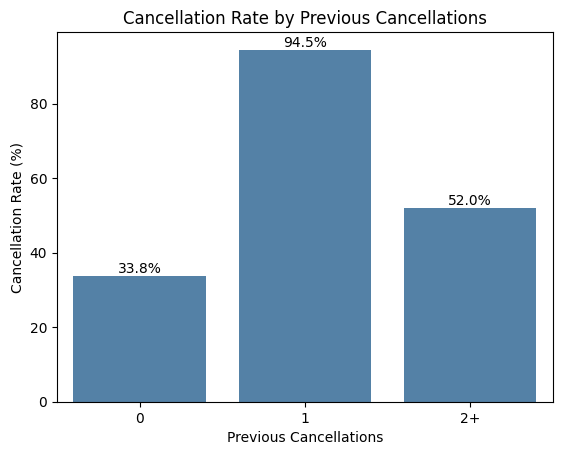

In [30]:
# 4.2.2.1 Previous Cancellations vs Cancellation

cancel_rate = (
    df.groupby(
        np.where(
            df['previous_cancellations'] >= 2,
            '2+',
            df['previous_cancellations'].astype(str)
        ),
        observed=False
    )['is_canceled']
    .mean()
    .mul(100)
    .reset_index(name='cancellation_rate')
)

cancel_rate.rename(columns={'index': 'prev_cancel_group'}, inplace=True)

ax = sns.barplot(
    data=cancel_rate,
    x='prev_cancel_group',
    y='cancellation_rate',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Previous Cancellations')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Previous Cancellations')
plt.show()

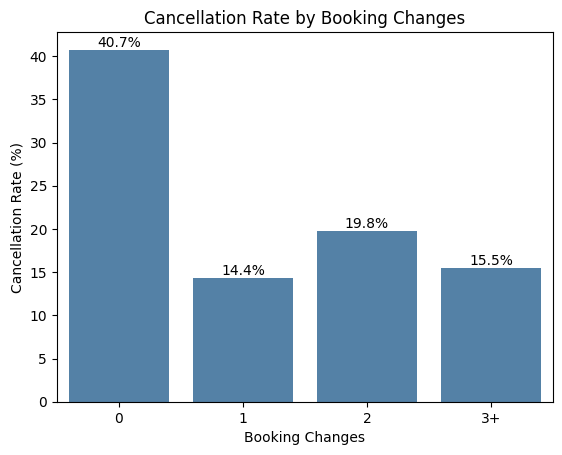

In [31]:
# 4.2.2.2 Booking Changes vs Cancellation

booking_changes_group = np.where(
    df['booking_changes'] >= 3,
    '3+',
    df['booking_changes'].astype(str)
)

cancel_rate = (
    df.groupby(booking_changes_group)['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='cancellation_rate')
      .rename(columns={'index': 'booking_changes'})
)

ax = sns.barplot(
    data=cancel_rate,
    x='booking_changes',
    y='cancellation_rate',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Booking Changes')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Booking Changes')
plt.show()

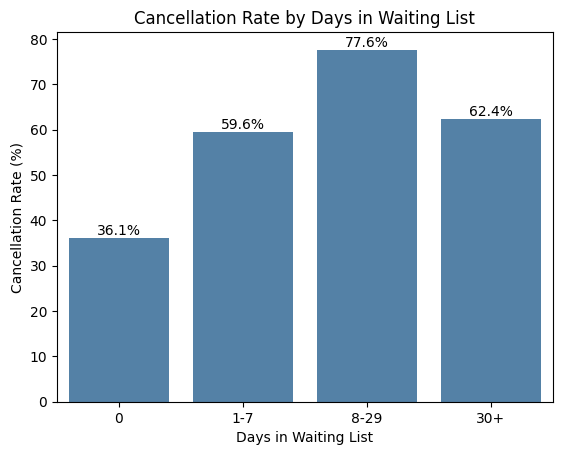

In [32]:
# 4.2.2.3 Days in Waiting List vs Cancellation

cancel_rate = (
    df.groupby(
        pd.cut(
            df['days_in_waiting_list'],
            bins=[-1, 0, 7, 29, float('inf')],
            labels=['0', '1-7', '8-29', '30+']
        ),
        observed=False
    )['is_canceled']
    .mean()
    .mul(100)
    .reset_index(name='cancellation_rate')
)

ax = sns.barplot(
    data=cancel_rate,
    x='days_in_waiting_list',
    y='cancellation_rate',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Days in Waiting List')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Days in Waiting List')
plt.show()

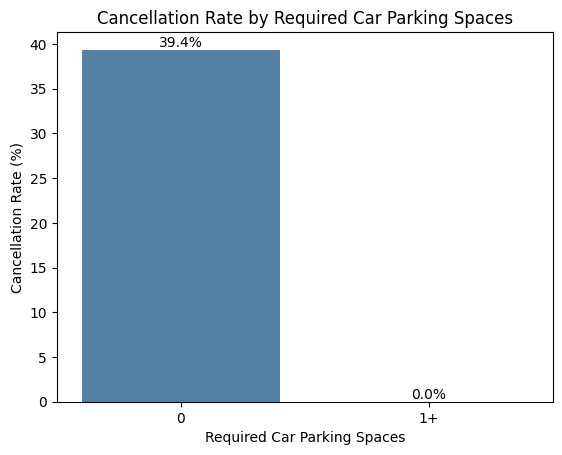

In [33]:
# 4.2.2.4 Required Car Parking Spaces vs Cancellation

required_car_parking_spaces_group = np.where(
    df['required_car_parking_spaces'] >= 1,
    '1+',
    df['required_car_parking_spaces'].astype(str)
)

cancel_rate = (
    df.groupby(required_car_parking_spaces_group)['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='cancellation_rate')
      .rename(columns={'index': 'required_car_parking_spaces'})
)

ax = sns.barplot(
    data=cancel_rate,
    x='required_car_parking_spaces',
    y='cancellation_rate',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Required Car Parking Spaces')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Required Car Parking Spaces')
plt.show()

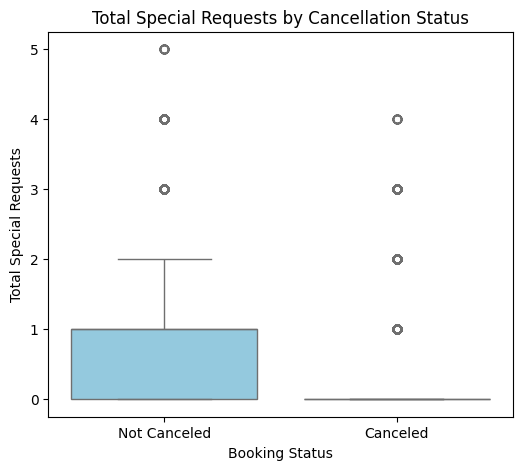

In [34]:
# 4.2.2.5 Total of Special Requests vs Cancellation

df_plot = df.copy()
df_plot['is_canceled'] = df_plot['is_canceled'].map({
    0: 'Not Canceled',
    1: 'Canceled'
})

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_plot,
    x='is_canceled',
    y='total_of_special_requests',
    color='skyblue'
)

plt.title('Total Special Requests by Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Total Special Requests')

plt.show()

In [35]:
df.groupby('required_car_parking_spaces').agg(
    total=('is_canceled', 'count'),
    canceled=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean')
)

,total,canceled,cancel_rate
required_car_parking_spaces,,,
0,78070,30731,0.393634
1,5126,0,0.000000
2,22,0,0.000000
3,1,0,0.000000
8,2,0,0.000000


**Overview:**
1. Customers with 1 previous cancellation have the highest cancellation rate (94.5%), indicating that customers who have canceled before are much more likely to cancel again. Although the cancellation rate drops to 52.0% for customers with 2 or more previous cancellations, it is still considerably higher than for those with no history of cancellations.
2. Bookings with no changes have the highest cancellation rate (40.7%). In contrast, bookings that have been modified at least once show much lower cancellation rates (14.4%–19.8%), suggesting that customers who update their reservations are more likely to follow through with their stay.
3. Bookings with longer waiting times tend to have higher cancellation rates. The highest rate is observed for bookings waiting 8–29 days (77.6%).
4. Bookings without parking requirements had a cancellation rate of 39.4%. However, No cancellations were observed among bookings that requested at least one parking space. This indicates that every customer that require parkings are less likely to cancel their reservations.
5. Most canceled bookings have no special requests. The distribution for canceled bookings is heavily concentrated at zero, indicating that customers who do not request additional services are more likely to cancel their reservations.

---

## **Section 5. Data Preparation**
This section outlines the preprocessing steps required to transform our cleaned dataset into a format optimal for machine learning algorithms. To prevent data leakage, we will split our data into training and testing sets before fitting any scalers, encoders, or resampling techniques.

### **5.1 Initialization**

In [36]:
# Define feature and target

target = df["is_canceled"]
feature = df.drop(columns="is_canceled")

### **5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

In [37]:
# split into train and test
x_train, x_test, y_train, y_test = train_test_split(feature,
                                                    target,
                                                    stratify=target,
                                                    test_size=0.2,
                                                    random_state=RANDOM_STATE)

# reset index
x_train.reset_index(inplace=True, drop=True)
x_test.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

# print x_train, y_train shape
print('x_train:', x_train.shape, '| x_test:', x_test.shape)
print('Proporsi target train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Proporsi target test :', y_test.value_counts(normalize=True).round(3).to_dict())

x_train: (66576, 10) | x_test: (16645, 10)
Proporsi target train: {0: 0.631, 1: 0.369}
Proporsi target test : {0: 0.631, 1: 0.369}


### **5.3 Handling Imbalanced Data (if relevant)**

> The target variable has a relatively balanced class distribution (63% : 37%). So resampling was not necessary.

### **5.4 Data Transformation (Feature Engineering)**


#### 5.4.1 High-Cardinality Categorical Encoding (`country`)

In [38]:
# Initialize the BinaryEncoder
be = BinaryEncoder(cols=['country'])

# Fit on training and transform both
X_train_encoded = be.fit_transform(x_train)
X_test_encoded = be.transform(x_test)

print([col for col in X_train_encoded.columns if 'country' in col])
X_train_encoded[[col for col in X_train_encoded.columns if 'country' in col]].tail()

['country_0', 'country_1', 'country_2', 'country_3', 'country_4', 'country_5', 'country_6', 'country_7']


,country_0,country_1,country_2,country_3,country_4,country_5,country_6,country_7
66571,0,0,0,0,1,1,0,1
66572,0,0,0,0,0,0,0,1
66573,0,0,1,0,1,0,0,1
66574,0,0,1,0,1,1,1,1
66575,0,0,0,1,1,1,1,1


In [39]:
X_train_encoded

,country_0,country_1,country_2,country_3,country_4,country_5,country_6,country_7,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests
0,0,0,0,0,0,0,0,1,Online TA,0,1,No Deposit,0,Transient,A,0,0
1,0,0,0,0,0,0,0,1,Offline TA/TO,1,0,Non Refund,0,Transient-Party,A,0,0
2,0,0,0,0,0,0,0,1,Online TA,0,2,No Deposit,0,Transient,A,0,0
3,0,0,0,0,0,0,0,1,Offline TA/TO,0,0,Non Refund,39,Transient,A,0,0
4,0,0,0,0,0,0,1,0,Groups,0,0,No Deposit,0,Transient-Party,E,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66571,0,0,0,0,1,1,0,1,Online TA,0,0,No Deposit,0,Transient,E,0,0
66572,0,0,0,0,0,0,0,1,Offline TA/TO,0,0,Non Refund,0,Transient,A,0,0
66573,0,0,1,0,1,0,0,1,Online TA,0,0,No Deposit,0,Transient,A,0,1
66574,0,0,1,0,1,1,1,1,Direct,0,1,No Deposit,0,Transient,A,0,0


#### 5.4.2 Low-Cardinality Categorical Encoding
Now we apply One Hot Encoding to nominal features with low cardinality (`market_segment`, `deposit_type`, `customer_type`, `reserved_room_type`). We drop the first category (drop='first') to mitigate multicollinearity

In [40]:
low_card_cols = ['market_segment', 'deposit_type', 'customer_type', 'reserved_room_type']

# Initialize OHE
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and transform on the training columns
X_train_ohe_raw = ohe.fit_transform(X_train_encoded[low_card_cols])
X_test_ohe_raw = ohe.transform(X_test_encoded[low_card_cols])

# Convert to DataFrame with clean column names
ohe_col_names = ohe.get_feature_names_out(low_card_cols)
X_train_ohe = pd.DataFrame(X_train_ohe_raw, columns=ohe_col_names, index=X_train_encoded.index)
X_test_ohe = pd.DataFrame(X_test_ohe_raw, columns=ohe_col_names, index=X_test_encoded.index)

X_train_encoded = X_train_encoded.drop(columns=low_card_cols).join(X_train_ohe)
X_test_encoded = X_test_encoded.drop(columns=low_card_cols).join(X_test_ohe)

print(f"shape after categorical encoding: {X_train_encoded.shape}")
X_train_encoded.head()

shape after categorical encoding: (66576, 33)


,country_0,country_1,country_2,country_3,country_4,country_5,country_6,country_7,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P
0,0,0,0,0,0,0,0,1,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,1,1,0,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,1,0,2,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,1,0,0,39,0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#### 5.4.3 Numerical Feature Scaling
Because features like `days_in_waiting_list` and `booking_changes` are heavily skewed and contain large outliers, we use RobustScaler to normalize them based on the median and IQR rather than the mean and variance.

In [41]:
num_cols = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

# Initialize RobustScaler
scaler = RobustScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Fit on training and scale both numerical subsets
X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_encoded[num_cols])

X_train_scaled[num_cols].head()

,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,2.0,0.0,0.0,0.0
3,0.0,0.0,39.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


### **5.5 Feature Selection**
Before passing our engineered dataset into machine learning algorithms, we must evaluate the predictive utility of our features. Feature selection helps reduce model complexity, minimize training time, and prevent overfitting by eliminating redundant, low-variance, or non-informative features.

For this dataset, we will evaluate features based on two criteria:
1. **Variance Check:** Drop features with zero variance (features where every single row has the same value).
2. **Multicollinearity & Domain Check:** Assess if any transformed features are perfectly collinear or structurally redundant.


In [42]:
# Identify Zero-Variance Features
zero_var_cols = [col for col in X_train_scaled.columns if X_train_scaled[col].var() == 0]

print(f"Zero-variance features found: {zero_var_cols}")

# Check Feature Correlations
numerical_features = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

correlation_matrix = X_train_scaled[numerical_features].corr()
print("\n--- Correlation Matrix of Core Numerical Features ---")
print(correlation_matrix.round(2))

features_to_drop = zero_var_cols

X_train_final = X_train_scaled.drop(columns=features_to_drop)
X_test_final = X_test_scaled.drop(columns=features_to_drop)

print(f"\nFinal Training Data Shape: {X_train_final.shape}")
print(f"Final Testing Data Shape: {X_test_final.shape}")

Zero-variance features found: []

--- Correlation Matrix of Core Numerical Features ---
                             previous_cancellations  booking_changes  \
previous_cancellations                         1.00            -0.03   
booking_changes                               -0.03             1.00   
days_in_waiting_list                           0.01            -0.01   
required_car_parking_spaces                   -0.02             0.07   
total_of_special_requests                     -0.05             0.06   

                             days_in_waiting_list  \
previous_cancellations                       0.01   
booking_changes                             -0.01   
days_in_waiting_list                         1.00   
required_car_parking_spaces                 -0.03   
total_of_special_requests                   -0.08   

                             required_car_parking_spaces  \
previous_cancellations                             -0.02   
booking_changes                         

* No features were found to have zero variance after preprocessing. This confirms that every single feature has varying data points. There are no static, useless columns that are identical for every row.

* The core numerical features have low correlations with each other (all coefficients are under 0.10). This means that there is almost zero multicollinearity among the numeric predictors.

---

## **Section 6. Model Development**
In this section, we build, benchmark, and optimize our model by transitioning our manual preprocessing steps from Section 5 into a scikit-learn framework

### **6.1 Initialization**

In [43]:
NUMERIC_COLS = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

CATEGORICAL_LOW_COLS = [
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]

CATEGORICAL_HIGH_COLS = ['country']

### **6.2 Developing the Model Pipeline**
we encapsulate our data transformations into a unified *ColumnTransformer*. By embedding this preprocessor directly inside an *imblearn.pipeline.Pipeline* alongside our estimators, we can guarantee that all scaling and encoding steps are fit only on the training folds of each cross-validation loop.

In [44]:
# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", RobustScaler(), NUMERIC_COLS),
        ("categorical_low", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CATEGORICAL_LOW_COLS),
        ("categorical_high", BinaryEncoder(), CATEGORICAL_HIGH_COLS)
    ]
)

# Define Base Models
models = {
    # Linear & Instance based
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    
    # Tree based
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    
    # Ensemble (Bagging & Boosting)
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE),
    'Bagging (Trees)': BaggingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
}

# Add Meta Ensembles (Voting & Stacking)
estimators_list = [
    ('log_reg', models['Logistic Regression']),
    ('rf', models['Random Forest']),
    ('xgb', models['XGBoost'])
]

models['Voting Classifier'] = VotingClassifier(estimators=estimators_list, voting='soft')
models['Stacking Classifier'] = StackingClassifier(
    estimators=estimators_list, 
    final_estimator=LogisticRegression(random_state=42)
)

pipeline = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('classifier', LogisticRegression())
    ])

display(pipeline)

/Users/rafiandrianto/Desktop/Purwadhika/.venv/lib/python3.12/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical_low', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [45]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = []

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_validate(
        pipeline, 
        x_train, 
        y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        return_train_score=True,
        n_jobs=-1,
        verbose=1
    )
    
    cv_results.append({
        'Model': name,
        'Mean Train Score': scores['train_accuracy'].mean(),
        'Mean Test Score': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'Fit Time (s)': scores['fit_time'].mean()
    })

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    4.6s remaining:    6.9s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   23.2s remaining:   34.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   25.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.9s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.0s remaining:    7.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_

### **6.3 Model Benchmarking (Comparing model base performance)**

In [46]:
benchmark_df = pd.DataFrame(cv_results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
benchmark_df

,Model,Mean Train Score,Mean Test Score,Precision,Recall,F1-Score,ROC-AUC,Fit Time (s)
0,XGBoost,0.816071,0.812140,0.774233,0.693512,0.731649,0.893611,0.462545
1,Stacking Classifier,0.819541,0.811704,0.773499,0.693309,0.731118,0.894125,18.405666
2,Random Forest,0.828095,0.807363,0.759323,0.700346,0.728578,0.888393,3.160613
3,Extra Trees,0.828102,0.808174,0.763757,0.695749,0.728114,0.883589,3.175292
4,Decision Tree,0.828102,0.806582,0.759990,0.696034,0.726557,0.878456,0.383389
5,Bagging (Trees),0.827040,0.804900,0.753862,0.700386,0.726104,0.885273,0.740026
6,Voting Classifier,0.819323,0.810878,0.793160,0.660118,0.720463,0.891286,3.732069
7,Gradient Boosting,0.799684,0.799267,0.800388,0.608054,0.691069,0.879391,8.434899
8,KNN,0.793540,0.780191,0.721938,0.660443,0.689033,0.850909,0.173141
9,Logistic Regression,0.778727,0.777998,0.775624,0.561237,0.651176,0.849498,1.369370


* All 11 benchmarked architectures demonstrate strong generalization without overfitting. The variance gap between training accuracy (*Mean Train Score*) and validation accuracy (*Mean Test Score*) remains minimal across all models

* Top Model — XGBoost
   * Achieved the highest test score leading with an F1-Score of 0.731, Accuracy of 81.21%, and ROC-AUC of 0.8936
   * Fitting in just 0.51 seconds, XGBoost outperforms meta models like the Stacking Classifier (20.53 seconds) in computational efficiency while delivering slightly higher accuracy and F_1 score.


Based on the benchmark results, **XGBoost** is selected as the primary candidate model for hyperparameter tuning in Section 6.4 to optimize precision-recall tradeoffs for booking cancellation risk.

### **6.4 Hyperparameter Tunning**
Having established that **XGBoost** achieves the strongest baseline performance with minimal fit time, we now optimize its primary hyperparameters.

To determine the most suitable evaluation metric, we evaluate the asymmetric business costs of prediction errors:
1. **False Positives (Precision):** The model predicts a guest will cancel but they actually show up
   * Business Impact: May lead to overbooking or premature room reallocation

2. **False Negatives (Recall):** The model predicts a guest will show up but they canceled.
   * Business Impact: Unoccupied rooms and direct loss of room revenue

Because uncaptured cancellations (False Negatives) directly hurt the revenue, identifying as many true cancellations as possible (**Recall**) is important. However, chasing 100% Recall without constraint would cause widespread false alarms (**Precision**), damaging guest relations and operational planning. Therefore, we select the **F1-Score** (mean of precision and recall) as our primary metric for RandomizedSearchCV

In [47]:
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

param_distributions = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__scale_pos_weight': [1.0, 1.2, 1.5]
}


scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    scoring=scoring_metrics,
    refit='f1', # Optimize primarily for F1-Score
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

xgb_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=300, classifier__scale_pos_weight=1.0, classifier__subsample=0.8; total time=   1.7s
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=300, classifier__scale_pos_weight=1.0, classifier__subsample=0.8; total time=   1.8s
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=300, classifier__scale_pos_weight=1.0, classifier__subsample=0.8; total time=   1.8s
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=300, classifier__scale_pos_weight=1.0, classifier__subsample=0.8; total time=   1.9s
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=5, clas

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False

In [48]:
results_df = pd.DataFrame(xgb_search.cv_results_)

# Filter down to the winning iteration index
best_idx = xgb_search.best_index_

tuning_summary = pd.DataFrame([{
    'Model Stage': 'Base XGBoost',
    'Mean Train Score': benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'Mean Train Score'].values[0],
    'Mean Val Score': benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'Mean Test Score'].values[0],
    'Precision': benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'Precision'].values[0],
    'Recall': benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'Recall'].values[0],
    'F1-Score': benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'F1-Score'].values[0],
    'ROC-AUC': benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'ROC-AUC'].values[0]
}, {
    'Model Stage': 'Tuned XGBoost',
    'Mean Train Score': results_df.loc[best_idx, 'mean_train_accuracy'],
    'Mean Val Score': results_df.loc[best_idx, 'mean_test_accuracy'],
    'Precision': results_df.loc[best_idx, 'mean_test_precision'],
    'Recall': results_df.loc[best_idx, 'mean_test_recall'],
    'F1-Score': results_df.loc[best_idx, 'mean_test_f1'],
    'ROC-AUC': results_df.loc[best_idx, 'mean_test_roc_auc']
}])

display(tuning_summary)
print(xgb_search.best_params_)

,Model Stage,Mean Train Score,Mean Val Score,Precision,Recall,F1-Score,ROC-AUC
0,Base XGBoost,0.816071,0.812140,0.774233,0.693512,0.731649,0.893611
1,Tuned XGBoost,0.819282,0.799958,0.710483,0.773520,0.740621,0.891167


{'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 1.5, 'classifier__n_estimators': 300, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 1.0}


> The overall F1-Score increased from 0.7316 to 0.7408. confirming that the metric gain in Recall outweighed the slight tradeoff in precision

### **6.5 Best Model Evaluation**
To ensure the tuned **XGBoost** model generalizes effectively, we evaluate its performance on the test dataset that was isolated before


In [49]:
best_model = xgb_search.best_estimator_

y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

y_train_proba = best_model.predict_proba(x_train)[:, 1]
y_test_proba = best_model.predict_proba(x_test)[:, 1]

print(f"F1-Score (Train): {f1_score(y_train, y_train_pred):.2%}")
print(f"F1-Score (Test):  {f1_score(y_test, y_test_pred):.2%}\n")

print(f"ROC-AUC (Train):  {roc_auc_score(y_train, y_train_proba):.2%}")
print(f"ROC-AUC (Test):   {roc_auc_score(y_test, y_test_proba):.2%}\n")

print(classification_report(y_test, y_test_pred))

F1-Score (Train): 76.42%
F1-Score (Test):  74.18%

ROC-AUC (Train):  91.27%
ROC-AUC (Test):   89.33%

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     10499
           1       0.71      0.77      0.74      6146

    accuracy                           0.80     16645
   macro avg       0.79      0.80      0.79     16645
weighted avg       0.81      0.80      0.80     16645



#### 6.5.1 Threshold Optimization
By default, standard classification models apply a probability threshold of 0.50($\hat{y} = 1 if P \ge 0.50$). However, because business priorities vary between avoiding vacant rooms and minimizing false warnings, we evaluate threshold variations across [0.10, 0.90] to optimize the F1-score.

In [50]:
y_test_pred = best_model.predict(x_test)

# Threshold optimization
thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_test_proba >= t).astype(int)

    score = f1_score(y_test, y_pred_temp)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

# Prediction using optimized threshold
y_test_pred_new = (y_test_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred_new))

Best Threshold : 0.48
Best F1 Score  : 0.7439
              precision    recall  f1-score   support

           0       0.87      0.79      0.83     10499
           1       0.69      0.81      0.74      6146

    accuracy                           0.80     16645
   macro avg       0.78      0.80      0.79     16645
weighted avg       0.81      0.80      0.80     16645



The best threshold from the optimization process is 0.49, resulting an F1-score of 74%.
Because it is very close to the default threshold (0.50), indicating that the default decision threshold is already close to optimal.

**Insight**:
1. The model detects more cancellation.
> Recall before vs after threshold showing increase from 0.77 to 0.80. This means the model able to identifies more customers who actually cancel their bookings.
2. More cancellations detected but increase False Positive
> Precission before vs after threshold showing decrease from 0.71 to 0.70. This means more bookings are predicted as canceled even though some of them will not actually cancel.
3. Even though Precision decreases and Recall increases, the F1-score remains around 74%, indicating that the model remains consistent.

#### 6.5.2 Confusion Matrix & Threshold Trade-Off
To better understand the impact of threshold optimization, we visualize the confusion matrices for both the default threshold (0.50) and the optimized threshold (0.49). This comparison highlights the changes in correct and incorrect predictions for each class.

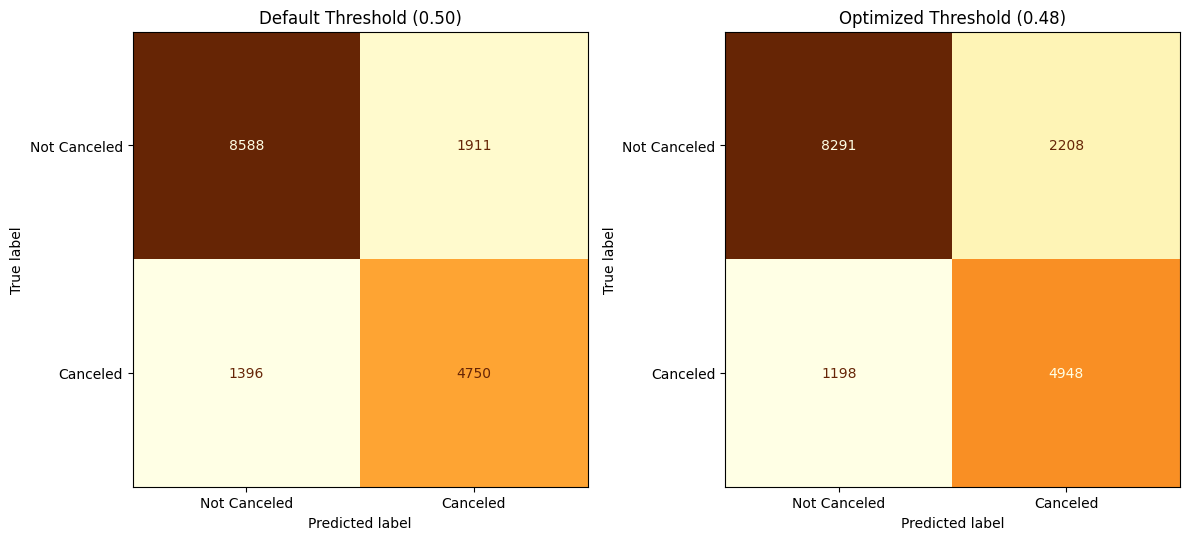

In [51]:
# Confusion Matrix before and after threshold
cm_default = confusion_matrix(y_test, y_test_pred)
cm_threshold = confusion_matrix(y_test, y_test_pred_new)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=["Not Canceled", "Canceled"]
).plot(ax=axes[0], cmap="YlOrBr", colorbar=False)

axes[0].set_title("Default Threshold (0.50)")

ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["Not Canceled", "Canceled"]
).plot(ax=axes[1], cmap="YlOrBr", colorbar=False)

axes[1].set_title(f"Optimized Threshold ({best_threshold:.2f})")

plt.tight_layout()
plt.show()

**Overview:**
1. After using customized threshold from 0.50 to 0.49, the model identifies more canceled bookings (TP: 4,751 to 4,910) and misses fewer actual cancellations (FN: 1,395 to 1,236). Identifying more potential cancellations allows the hotel to take action earlier, such as sending reminders, offering promotions, or confirming reservations with guests.

2. However, this also increases the number of false alarms, where bookings are predicted as canceled but are actually not (FP: 1,900 to 2,140), while the number of correctly identified non-canceled bookings decreases (TN: 8,599 to 8,359). The increase in false positive predictions means the hotel may follow up with more guests who were not actually going to cancel.

3. Despite the Precision-Recall tradeoff, the overall F1-Score remains consistently high around 74%, proving the model's reliability across flexible operational thresholds. Overall, the lower threshold can identify more cancellations but also makes more incorrect cancellation predictions.

### **6.6 Model Explanation and Interpretation**
While predictive performance (F1-Score, ROC-AUC) validates how well a model predicts, model interpretability explains why it makes those predictions. Understanding the decision logic builds stakeholder trust and produce actionable business insights for hotel management.

#### **6.6.1 How XGBoost works**

XGBoost (eXtreme Gradient Boosting) belongs to the family of Gradient Boosted Decision Trees (GBDT) is an optimized gradient boosting algorithm that combines multiple weak models into a stronger, high-performance model. Unlike random forests (which train many deep decision trees independently in parallel) XGBoost builds trees sequentially, with each new tree designed specifically to correct the residual errors made by the previous trees.

- **The model starts with a base learner** by creating a simple decision tree to make initial predictions.
- **Calculate the errors**: After training the first tree the errors between the predicted and actual values are calculated.
- **Train the next tree**: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree.
- **Repeat the process**: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.
- **Combine the predictions**: The final prediction is the sum of the predictions from all the trees.

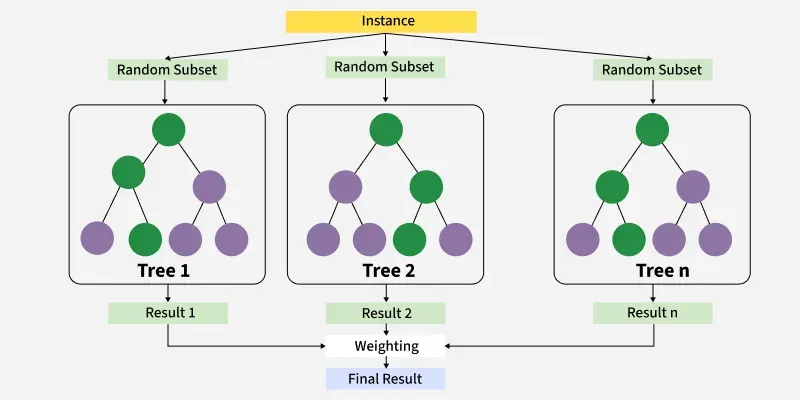

#### **6.6.2 Feature Importance (SHAP Analysis)**
To explain how our tuned XGBoost model makes predictions across the overall dataset, we use SHAP (SHapley Additive exPlanations) values. SHAP provides an unbiased measure of global feature impact by quantifying how much each variable shifts the model's prediction toward or away from cancellation

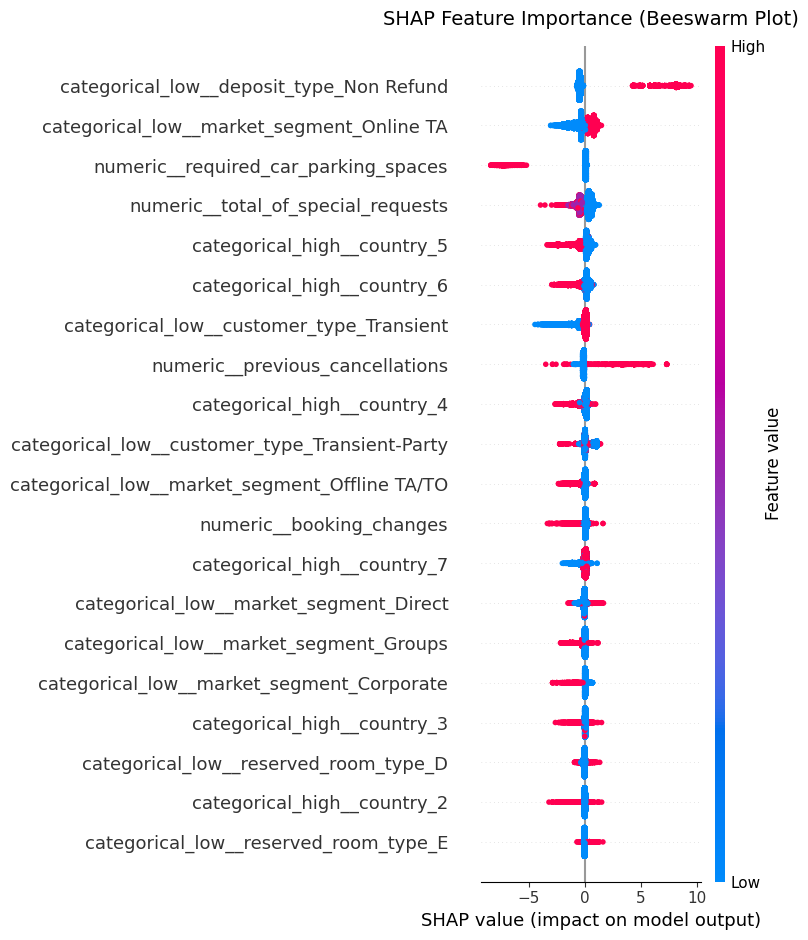

In [52]:
explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
x_test_transformed = best_model.named_steps['preprocessing'].transform(x_test)
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()

# Calculate SHAP values for test data
shap_values = explainer(x_test_transformed)

# Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance (Beeswarm Plot)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Each point represents a single booking from the test set:
* Position on X-axis (SHAP Value): Represents the impact on the predicted log-odds of cancellation
  * Positive SHAP Value (> 0): Increases cancellation probability
  * Negative SHAP Value (< 0): Decreases cancellation probability
* Color: Represents the feature's actual value (Red = High, Blue = Low)

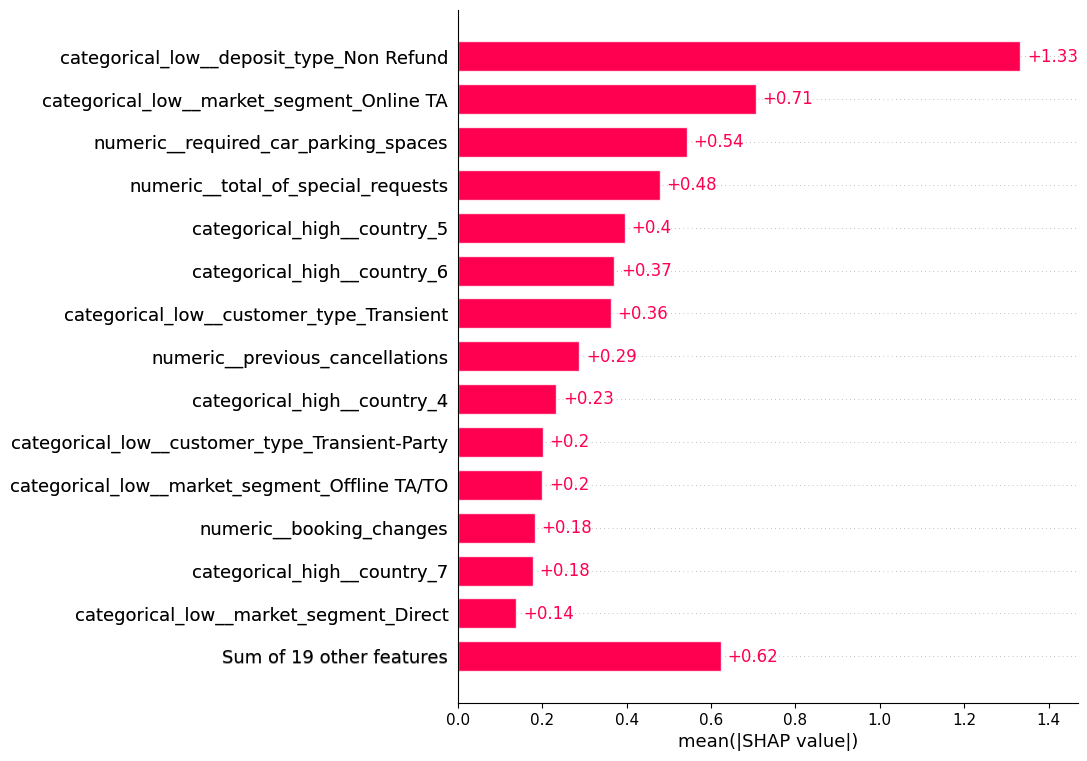

In [53]:
x_test_df = pd.DataFrame(
    best_model.named_steps['preprocessing'].transform(x_test),
    columns=feature_names
)

shap_values = explainer(x_test_df)

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15)

**1. Non-Refundable Deposi**t (`deposit_type`)
* Data Distribution: No Deposit (87.73%), Non Refund (12.14%), Refundable (0.13%)

* High feature values (red dots) form a distinct cluster far to the right with extreme positive SHAP values (+4.0 to +9.0)

* Surprisingly, non-refundable bookings in this dataset are a strong indicator of higher cancellation risk because they are likely tied to large tour operators and group bookings. These wholesale agencies frequently reserve massive blocks of rooms or tickets in advance, only to cancel unsold inventory later through administrative updates or automatic releases. Consequently, while individual travelers rarely cancel non-refundable reservations, the routine cleanup habits of these large group channels completely flip the expected logic and skew the data.

**2. Booking Channels & Customer Types (`market_segment` & `customer_type`)**
* Data Distribution: Online TA (47.35%), Transient (75.00%)

* Online TA bookings push positive SHAP values, while Direct and Corporate segments cluster on the negative side

* Online Travel Agencies see higher booking volatility due to their low-friction platforms and flexible cancellation policies, whereas direct bookings and corporate channels provide much more stable and committed customer demand

**3. Parking Space Requirements (`required_car_parking_spaces`)**
* Data Distribution: 0 spaces (93.80%), $\ge$ 1 space (6.20%)

* Zero requests (blue dots) sit neutral at 0.0, while requesting $\ge 1$ parking space (red dots) shifts sharply to the left (negative SHAP values down to -8.0)

* While cancellation risk remains normal for the 93.8% of customers who do not ask for parking, those who do request a space almost never cancel, making parking requests a foolproof sign that a guest will definitely show up.

**4. Historical Cancellations (`previous_cancellations`)**
* Data Distribution: 0 past cancellations (94.62%), $\ge$ 1 past cancellation (5.38%).

* Zero past cancellations (blue dots) hover around 0.0, while guests with prior cancellations (red dots) stretch significantly to the right (SHAP values up to +7.0)

* Customers who have canceled bookings in the past are highly likely to do it again, making a customer's reservation history one of the most reliable indicators of future cancellation risk.

**5. Engagement via Special Requests (`total_of_special_requests`)**
* Data Distribution: 0 requests (58.83%), 1+ requests (41.17%)

* Zero requests (blue dots) push slightly positive, whereas additional requests (1, 2, 3+) move the SHAP value to the left (negative log-odds).

* The more a customer interacts with their booking, the more likely they are to show up. (like choosing room layouts or requesting extra pillows—is a clear sign of high intent)


#### 6.6.3 Cost Benefit Analysis
Because feature variables in `reserved_room_type` anonymize room categories into letter codes (A through P), financial impact cannot be calculated. To resolve this, external market pricing data from hotels in Lisbon and the Algarve (geographic origins of the benchmark dataset (Nuno Antonio et al., 2018)) was scraped. The process includes room prices across 55 distinct hotels (25 in Lisbon and 30 in the Algarve) and contains 194 unique room listings in IDR (Indonesian Rupiah).

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **city** | String | Geographic location cluster (Lisbon or Algarve) |
| **hotel_name** | String | Name of the benchmark hotel property |
| **room_type_name** | String | Scraped room category description |
| **price** | Float64 | Scraped 1-night stay daily rate proxy in IDR (ADR) |
| **checkin** | String | Reservation check-in date (YYYY-MM-DD) |
| **checkout** | String | Reservation check-out date (YYYY-MM-DD) |
| **url** | String | Direct Booking.com reference URL for verification |

In [54]:
scraped_df = pd.read_csv('../data/web_scrapping/hotel_room_prices.csv')
scraped_df.head()

,city,hotel_name,room_type_name,price,checkin,checkout,url
0,Lisbon,"Maxime Boutique Hotel Avenida da Liberdade, Li...",Run of House,2750525.0,2026-08-08,2026-08-09,https://www.booking.com/hotel/pt/maxime.html?a...
1,Lisbon,"Maxime Boutique Hotel Avenida da Liberdade, Li...",Deluxe Twin Room,2925964.0,2026-08-08,2026-08-09,https://www.booking.com/hotel/pt/maxime.html?a...
2,Lisbon,"Maxime Boutique Hotel Avenida da Liberdade, Li...",Deluxe Double Room,3156563.0,2026-08-08,2026-08-09,https://www.booking.com/hotel/pt/maxime.html?a...
3,Lisbon,"Maxime Boutique Hotel Avenida da Liberdade, Li...",Dressing Room,3770565.0,2026-08-08,2026-08-09,https://www.booking.com/hotel/pt/maxime.html?a...
4,Lisbon,"Maxime Boutique Hotel Avenida da Liberdade, Li...",Bar Room,4000816.0,2026-08-08,2026-08-09,https://www.booking.com/hotel/pt/maxime.html?a...


To validate the room types scrapped data align with the dataset's anonymized codes, we analyze the behavioral patterns across room types:

In [55]:
# Group by room type to see their behavioral patterns
room_profiles = df.groupby('reserved_room_type').agg(
    volume=('is_canceled', 'count'),
    avg_special_requests=('total_of_special_requests', 'mean'),
    avg_parking=('required_car_parking_spaces', 'mean'),
    avg_changes=('booking_changes', 'mean')
).sort_values(by='volume', ascending=False)

print(room_profiles)


                    volume  avg_special_requests  avg_parking  avg_changes
reserved_room_type                                                        
A                    59761              0.494855     0.045264     0.202724
D                    13505              0.784524     0.070048     0.214513
E                     4621              0.828392     0.150617     0.279160
F                     2032              0.739173     0.138780     0.352854
G                     1438              0.652295     0.207232     0.339360
B                      786              0.783715     0.039440     0.496183
C                      672              0.773810     0.186012     0.517857
H                      401              0.408978     0.264339     0.351621
L                        3              0.000000     0.000000     0.000000
P                        2              0.000000     0.000000     0.000000


* Standard / Economy Tier (Room A): Represents the massive baseline majority (59,761 bookings, 71.8%). It exhibits the lowest special requests (0.49), minimal parking demand (0.045), and low schedule modifications (0.20).

* Deluxe Tier (Room D): Represents a mid-tier volume product (13,505 bookings). Displays an increase in special requests (0.78), indicating higher guest expectations, while parking demand remains low (0.07).

* Family / Group Suites (Rooms E, F, G): Large capacity multi guest spaces (8,091 total bookings). Marked by an increase in parking demand (0.138 to 0.207) and elevated special requests (0.65 to 0.83), indicating family road trippers or group travelers requiring vehicles.

* Premium Executive / Business Tier (Rooms B, C, H): High margin executive spaces (1,859 total bookings). Shows the highest schedule volatility in the dataset (avg_changes from 0.35 to 0.51), typical of business travelers or high net worth individuals modifying their itineraries. Room H specifically demands the highest parking share (0.264).

* Outliers (Rooms L, P): Extremely low volume (5 total bookings) with zero special requests, parking, or schedule changes.

In [56]:
# Map scraped room descriptions to the 5 Behavioral Tiers
def map_room_description_to_tier(room_name):
    name = str(room_name).lower()
    
    if any(k in name for k in ['dormitory', 'bed in', 'hostel', 'pousada']):
        return 'L/P (Outliers)'

    elif any(k in name for k in ['executive', 'ocean view', 'sea view', 'penthouse', 'retreat', 'single', 'economy', 'budget']):
        return 'B/C/H (Premium Executive / Business)'

    elif any(k in name for k in ['family', 'suite', 'apartment', 'residence', 'two-bedroom', 'triple', 'quadruple']):
        return 'E/F/G (Family / Group Suites)'

    elif any(k in name for k in ['deluxe', 'premium', 'studio']):
        return 'D (Select / Deluxe)'

    else:
        return 'A (Standard / Economy)'


scraped_df['behavioral_tier'] = scraped_df['room_type_name'].apply(map_room_description_to_tier)

tier_price_matrix = scraped_df.groupby('behavioral_tier')['price'].agg(
    scraped_sample_count='count',
    mean_adr='mean',
    median_adr='median'
).reset_index()

tier_price_matrix['mean_adr_formatted'] = tier_price_matrix['mean_adr'].map('IDR {:,.0f}'.format)
tier_price_matrix['median_adr_formatted'] = tier_price_matrix['median_adr'].map('IDR {:,.0f}'.format)
print(tier_price_matrix[['behavioral_tier', 'scraped_sample_count', 'mean_adr_formatted', 'median_adr_formatted']].to_string(index=False))

                     behavioral_tier  scraped_sample_count mean_adr_formatted median_adr_formatted
              A (Standard / Economy)                    96      IDR 3,922,484        IDR 3,338,946
B/C/H (Premium Executive / Business)                    31      IDR 5,550,745        IDR 4,613,186
                 D (Select / Deluxe)                    25      IDR 4,716,615        IDR 4,368,238
       E/F/G (Family / Group Suites)                    34     IDR 11,613,679        IDR 6,391,610
                      L/P (Outliers)                     8        IDR 639,799          IDR 451,929


By grouping these 194 market samples into the 5 validated behavioral tiers, we establish a clear Average Daily Rates (ADR) for each category. Standard rooms average *IDR 3,922,484*, mid tier Deluxe rooms *IDR 4,716,615*, Executive/Business suites *IDR 5,550,745*, and large Family/Group Suites *IDR 11,613,679*. Next, we map these derived ADR back to the main dataset rows using their reserved_room_type codes.

In [57]:
# Create lookup dictionary mapping individual anonymized room codes to Tier Mean ADR
room_to_tier_adr = {
    'A': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'A (Standard / Economy)', 'mean_adr'].values[0],
    'D': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'D (Select / Deluxe)', 'mean_adr'].values[0],
    'E': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'E/F/G (Family / Group Suites)', 'mean_adr'].values[0],
    'F': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'E/F/G (Family / Group Suites)', 'mean_adr'].values[0],
    'G': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'E/F/G (Family / Group Suites)', 'mean_adr'].values[0],
    'B': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'B/C/H (Premium Executive / Business)', 'mean_adr'].values[0],
    'C': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'B/C/H (Premium Executive / Business)', 'mean_adr'].values[0],
    'H': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'B/C/H (Premium Executive / Business)', 'mean_adr'].values[0],
    'L': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'L/P (Outliers)', 'mean_adr'].values[0],
    'P': tier_price_matrix.loc[tier_price_matrix['behavioral_tier'] == 'L/P (Outliers)', 'mean_adr'].values[0]
}

df['estimated_adr'] = df['reserved_room_type'].map(room_to_tier_adr)
df[['reserved_room_type', 'estimated_adr']].head()

,reserved_room_type,estimated_adr
0,A,3.922484e+06
1,A,3.922484e+06
2,A,3.922484e+06
3,A,3.922484e+06
4,A,3.922484e+06


To model the real-world business impact on the test dataset, we establish the financial outcome equations for each cell of the Confusion Matrix:

| Outcome | Model Decision | Actual Status | Business Impact & Operational Mechanics | Financial Equation |
| :--- | :--- | :--- | :--- | :--- |
| **True Positive (TP)** | Predicted Canceled | Canceled | **Successful Intervention:** High-risk booking is flagged. Targeted retention campaign is deployed costing $C_{int}$. A fraction ($\beta$) of guests accept and keep their reservation. | $Loss_{TP} = (1 - \beta) \times ADR + C_{int}$ |
| **False Positive (FP)** | Predicted Canceled | Non-Canceled | **Wasted Operational Cost:** Guest was going to stay anyway. Targeted outreach is deployed needlessly, wasting the campaign expense. | $Loss_{FP} = C_{int}$ |
| **False Negative (FN)** | Predicted Non-Canceled | Canceled | **Unmitigated Revenue Loss:** Model fails to alert management. Room sits empty, losing full baseline room revenue. | $Loss_{FN} = ADR$ |
| **True Negative (TN)** | Predicted Non-Canceled | Non-Canceled | **Standard Operation:** Guest arrives as planned. No intervention deployed, no extra cost incurred. | $Loss_{TN} = 0$ |

* **Intervention Unit Cost ($C_{int}$):** IDR 50,000 per targeted booking. This covers automated messaging, staff re-confirmation workflows, or small loyalty/incentive perks.

* **Retention Recovery Rate ($\beta$):** 25%. A conservative hospitality industry benchmark for proactive retention and early re-booking campaigns. (Out of 4 guests who were going to cancel, 1 changes their mind and stays because of our outreach.)

* **Baseline Scenario ("Do Nothing"):** Represents the current situation where without an AI model, the hotel loses 100% of the room price ($ADR$) every time someone cancels.

In [58]:
# Map price to test dataframe
test_df = x_test.copy()
test_df['actual'] = y_test
test_df['pred'] = (best_model.predict_proba(x_test)[:, 1] >= best_threshold).astype(int)
test_df['adr'] = test_df['reserved_room_type'].map(room_to_tier_adr)

INTERVENTION_COST = 50_000
RECOVERY_RATE = 0.25

* **Net Savings:** The total money saved by using the AI model. We calculate this by taking the financial loss of doing nothing and subtracting the new model costs (losses from missed cancellations, wasted outreach, and partial losses from saved bookings).
$$\text{Net Savings} = \text{Loss}_{\text{Baseline}} - (\text{Loss}_{\text{FN}} + \text{Loss}_{\text{FP}} + \text{Loss}_{\text{TP}})$$

* **Return on Investment (ROI):** The financial return on every rupiah spent. It compares the net money saved against the total cost of reaching out to everyone flagged by the model (both correct and incorrect flags).
$$\text{ROI} = \left( \frac{\text{Net Savings}}{(\text{Count}_{\text{TP}} + \text{Count}_{\text{FP}}) \times C_{int}} \right) \times 100$$


In [59]:
# Every actual cancellation (actual == 1) is a 100% loss of ADR.
baseline_loss = test_df[test_df['actual'] == 1]['adr'].sum()

# Model
# FN Loss: Cancellations we missed -> Lose full ADR
fn_mask = (test_df['actual'] == 1) & (test_df['pred'] == 0)
loss_fn = test_df.loc[fn_mask, 'adr'].sum()

# FP Loss: Unnecessary outreach -> Wasted intervention cost
fp_mask = (test_df['actual'] == 0) & (test_df['pred'] == 1)
loss_fp = len(test_df[fp_mask]) * INTERVENTION_COST

# TP Outcome: Flagged cancellations -> Cost incurred, but 25% revenue recovered
tp_mask = (test_df['actual'] == 1) & (test_df['pred'] == 1)
tp_count = len(test_df[tp_mask])
tp_adr_sum = test_df.loc[tp_mask, 'adr'].sum()

# Residual loss on TPs = Unrecovered ADR (75%) + Campaign costs for all TPs
loss_tp = ((1 - RECOVERY_RATE) * tp_adr_sum) + (tp_count * INTERVENTION_COST)

# Total Model Loss
model_loss = loss_fn + loss_fp + loss_tp

# Net Financial Savings & ROI
net_savings = baseline_loss - model_loss
total_campaign_cost = (tp_count + len(test_df[fp_mask])) * INTERVENTION_COST
roi = (net_savings / total_campaign_cost) * 100

In [60]:
print(f"Baseline Revenue Loss : IDR {baseline_loss:,.0f}")
print(f"Model Net Loss        : IDR {model_loss:,.0f}")
print(f"Net Recovered Revenue : IDR {net_savings:,.0f}")
print(f"Total Campaign Cost   : IDR {total_campaign_cost:,.0f}")
print(f"Model ROI             : {roi:.2f}%")

Baseline Revenue Loss : IDR 29,306,133,101
Model Net Loss        : IDR 23,894,170,145
Net Recovered Revenue : IDR 5,411,962,956
Total Campaign Cost   : IDR 357,800,000
Model ROI             : 1512.57%


* The tuned XGBoost model cuts cancellation losses from *IDR 29,306,133,101* down to *IDR 23,894,170,145*. This directly protects **IDR 5,411,962,956** in room revenue on the test set alone.

* The campaign only costs *IDR 357,800,000* to reach out to 7,156 flagged bookings (number of positive predictions). This yields a massive **1,512.57% ROI**, returning over *IDR 15.12* for every *IDR 1.00* spent.

## **Section 7. Model Deployment**

### **7.1 Export Model**

In [61]:
# Create a directory
os.makedirs('models', exist_ok=True)

model_filename = 'models/xgboost_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

### **7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

#### 7.2.1 Library & Environment Dependencies
| Dependency | Required Version | Purpose |
| :--- | :--- | :--- |
| **pandas** | `3.0.2` | Data Manipulation & Pipeline Input Structuring |
| **numpy** | `2.4.4` | Matrix & Array Computations |
| **scikit-learn** | `1.8.0` | Pipeline Execution, Scalers, Encoders, Base Models |
| **xgboost** | `3.2.0` | Tuned Gradient Boosting Model Engine |
| **feature-engine** | `1.9.4` | Outlier & Datetime Feature Engineering Transformers |
| **category-encoders** | `2.9.0` | Categorical Encoding Support |
| **imbalanced-learn** | `0.14.2` | Resampling Pipeline Compatibility |
| **shap** | `0.52.0` | Model Interpretability & Explanation Analysis |
| **matplotlib** | `3.10.9` | Diagnostic Plot Generation |
| **seaborn** | `0.13.2` | Exploratory & Performance Visualization |

#### 7.2.2 Expected Input Format
The serving endpoint must accept raw JSON payloads representing individual booking records or batch arrays. The pipeline handles missing values and categorical encoding natively, but raw input fields must adhere strictly to expected data types:

```json
{
  "country": "PRT",
  "market_segment": "Online TA",
  "previous_cancellations": 0,
  "booking_changes": 0,
  "deposit_type": "No Deposit",
  "days_in_waiting_list": 0,
  "customer_type": "Transient",
  "reserved_room_type": "A",
  "required_car_parking_space": 0,
  "total_of_special_request": 2
}
```

#### 7.2.3 Pipeline Reloading
The following production pattern demonstrates how an API service (e.g., FastAPI or Flask) reloads the pickled scikit-learn pipeline into memory upon startup and executes real-time probability scoring using the tuned decision threshold (0.49):

In [62]:
import pickle
import pandas as pd
from typing import Dict, Any, Union, List

class CancellationPredictionService:
    def __init__(self, model_path: str, threshold: float = 0.49):
        """
        Loads the serialized pipeline once at service initialization.
        """
        self.model_path = model_path
        self.threshold = threshold
        self.pipeline = self._load_pipeline()

    def _load_pipeline(self):
        """
        Loads the pickled sklearn pipeline from disk in binary read mode ('rb').
        """
        try:
            with open(self.model_path, 'rb') as file:
                pipeline = pickle.load(file)
            print(f"Pipeline successfully reloaded from: {self.model_path}")
            return pipeline
        except Exception as e:
            raise RuntimeError(f"Failed to load model pipeline: {str(e)}")

    def predict(self, payload: Union[Dict[str, Any], List[Dict[str, Any]]]) -> List[Dict[str, Any]]:
        """
        Executes prediction on incoming JSON payload(s).
        
        Parameters:
            payload: Single dictionary or list of feature dictionaries.
            
        Returns:
            List of dictionary results containing probability and binary decision.
        """
        # Ensure payload is formatted as a DataFrame
        if isinstance(payload, dict):
            input_df = pd.DataFrame([payload])
        else:
            input_df = pd.DataFrame(payload)

        # Get raw probabilities for positive class (Cancellation = 1)
        probabilities = self.pipeline.predict_proba(input_df)[:, 1]

        # Generate predictions based on optimal decision threshold (0.48)
        results = []
        for prob in probabilities:
            prob_val = float(prob)
            is_canceled = int(prob_val >= self.threshold)
            
            results.append({
                "is_canceled_prediction": is_canceled,
                "cancellation_probability": round(prob_val, 4),
                "decision_threshold": self.threshold,
                "risk_category": "High Risk" if is_canceled == 1 else "Low Risk"
            })

        return results


# Example Usage (Serving Layer Mockup)
if __name__ == "__main__":
    # Initialize service once during startup
    predictor = CancellationPredictionService(
        model_path='models/xgboost_model.pkl',
        threshold=0.49
    )

    # Corrected sample incoming payload (aligned with exact 10 model features)
    sample_booking = {
        "country": "PRT",
        "market_segment": "Online TA",
        "previous_cancellations": 0,
        "booking_changes": 0,
        "deposit_type": "No Deposit",
        "days_in_waiting_list": 0,
        "customer_type": "Transient",
        "reserved_room_type": "A",
        "required_car_parking_spaces": 0,
        "total_of_special_requests": 2
    }

    # Execute scoring
    prediction_result = predictor.predict(sample_booking)
    print("Inference Result:", prediction_result)

Pipeline successfully reloaded from: models/xgboost_model.pkl
Inference Result: [{'is_canceled_prediction': 1, 'cancellation_probability': 0.5254, 'decision_threshold': 0.49, 'risk_category': 'High Risk'}]


---

## **Section 8. Conclusion and Recommendation**
This project built a machine learning system to predict hotel booking cancellations. By upgrading from a basic classification model to a system optimized for actual hotel operations, the final solution directly stabilizes revenue while protecting the customer experience

### **8.1 Conclusion**

#### **8.1.1 Technical & Model Performance**
* The final production pipeline uses a tuned **XGBoost Classifier** packaged with automated preprocessing tools like RobustScaler, OneHotEncoder, and BinaryEncoder. This integrated setup ensures identical data handling during both training and live deployment, completely eliminating data leakage while making the system fully reproducible.

* Lowering the classification threshold from the standard 0.50 to 0.49 maximized the model's total business value. This optimal operating point creates the ideal balance between high recall (capturing potential cancellations early) and high precision (avoiding unnecessary interventions on stable bookings).

* Model predictions are driven by:
  * **Non-Refundable Deposits (`deposit_type`):** Counterintuitively exhibited the strongest positive push toward cancellation risk (+4.0 to +9.0 SHAP value). Most non-refundable bookings are from large travel agencies and group bookings that are often canceled together.

  * **Online Travel Agencies (`market_segment`):** OTA channels introduce higher volatility compared to Direct or Corporate segments due to low-friction booking mechanisms.

  * **Historical Cancellations (`previous_cancellations`):** Prior cancellation history strongly predicts repeat cancellation behavior (SHAP values up to +7.0). Guests with previous cancellations are more likely to cancel again.

  * **Commitment Signals (`required_car_parking_space` & `total_of_special_request`):** Guests requesting parking space ($\ge$ 1) or engaging via special requests (extra pillows, room preferences) show significantly higher showup intent, shifting SHAP values heavily into negative (down to -8.0).

#### **8.1.2 Business & Financial Impact**
By spotting cancellation risks early, hotel management can protect revenue and keep guests comfortable without relying on strict rules that frustrate reliable customers. Deploying this predictive model on the test set reduced cancellation losses from *IDR 29,306,133,101* Billion down to *IDR 23,894,170,145*, instantly *saving IDR 5,411,962,956* in net room revenue while safely optimizing occupancy and overbooking strategies. This precise approach is exceptionally capital-efficient: spending just IDR 50,000 per outreach resulted in a total operational budget of *IDR 357,800,000* across 7,156 flagged bookings, driving an extraordinary 1,512.57% ROI and returning IDR 15.12 for every IDR 1.00 spent

### **8.2 Recommendation**

#### **8.2.1 Model Maintenance & Technical Roadmap**
* **Routine model updates:** Schedule model retraining every three months with fresh booking data to keep predictions sharp and aligned with current market patterns.

* **Live testing:** Run a controlled A/B test in a staging environment by applying the model's strategies to half of the incoming bookings to measure the actual revenue saved compared to the unchanged group.

* **Real-time drift checks:** Set up automated systems using tools like Evidently AI to track data drift (changes in guest behavior) and concept drift (shifts in travel trends due to seasons or the economy) over time.

#### **8.2.2 Strategic Business Action Plan**
* **Re-evaluate Deposit Strategies:**
- Use flexible deposit options for high-risk bookings, allowing guests to modify their reservation within a limited period instead of canceling immediately.
- Keep non-refundable deposits for low-risk bookings.

* **Engagement for OTA customers:**
- Send reminder emails or messages to OTA guests 3–7 days before arrival to confirm their booking.
- Use special offers for high-risk OTA guests to encourage them not to cancel their bookings

* **Historical Cancellation Management:**
- Offer flexible date changes instead of cancellations
- Request booking reconfirmation a few days before arrival
- Offer promo discount or free complimentary if guests make repeat bookings without previous cancellations

* **Increase Guests Commitments:**
- Encourage guests to add special requests during the booking process
- Offer discount or special packages promotion for booking with added requests